# Projet : Recherche Opérationnelle

## Sommaire

1. Contexte et problématique
2. Modélisation du graphe
   - 2.1 Définition du graphe
   - 2.2 Blocage des routes
   - 2.3 Définition des matrices de coût
   - 2.4 Dynamique de la tournée
3. Modélisation du problème
   - 3.1 Variables de décision
   - 3.2 Définition du temps
   - 3.3 Fonction objectif
   - 3.4 Contraintes
     - 3.4.1 Nombre de passages
     - 3.4.2 Visite de tous les sommets
4. Complexité du problème
   - 4.1 Version décisionnelle
   - 4.2 Appartenance à NP
     - Certificat
     - Taille de l'entrée
     - Étape 1 : Vérification du domaine des variables
     - Étape 2 : Vérification des contraintes de flux
     - Étape 3 : Vérification de la visite des sommets
     - Étape 4 : Vérification de la cohérence avec le graphe
     - Étape 5 : Calcul du coût total
     - Étape 6 : Comparaison avec le seuil
     - Complexité totale
   - 4.3 NP-difficulté
     - 4.3.1 Instance du TSP
     - 4.3.2 Construction
     - 4.3.3 Interprétation
     - 4.3.4 Preuve d'équivalence
   - 4.4 Conclusion
5. Modélisation des graphes initiaux
6. Méthodes de résolution
   - 6.1 Positionnement sur les graphes complets
   - 6.2 Plan d'expérience
     - Objectif
     - Protocole général
     - Phase 1 : Calibrage des hyperparamètres (OFAT)
     - Phase 2 : Validation des meilleurs paramètres
     - Phase 3 : Sensibilité aux paramètres d'instance
     - Phase 4 : Robustesse (100 runs)
     - Indicateurs finaux
   - 6.3 Relaxation continue et borne inférieure
     - Principe de la relaxation continue
     - Borne inférieure
     - Formulation mathématique relaxée
     - Implémentation Python (PuLP)
   - 6.4 Choix des méthodes de résolution
     - 6.4.1 Colonie de fourmis (ACO)
       - Principe général
       - Construction d'une solution
       - Mise à jour des phéromones
       - Adaptations au problème dynamique
     - 6.4.2 Algorithme génétique (GA)
       - Principe général
       - Représentation d'une solution
       - Fonction d'évaluation (fitness)
       - Population initiale
       - Sélection
       - Croisement
       - Mutation
       - Élitisme
7. Implémentation du GA
   - Optimisation des hyperparamètres (OFAT)
     - Résultats principaux
     - Analyse
     - Conclusion générale
   - Impact des paramètres d'instance
     - Objectif de l'étude
     - Pourquoi utiliser l'algorithme génétique ?
     - Paramètres étudiés
     - Impact du nombre de matrices de coût
     - Impact de la probabilité de blocage
     - Impact du nombre de sommets
   - Influence du nombre de matrices dynamiques (K)
   - Influence de la probabilité de blocage
   - Influence du nombre de sommets (n)
   - Résultat final et écart à la borne inférieure
8. Implémentation du ACO
   - Optimisation des hyperparamètres (OFAT)
     - Résultats principaux
     - Analyse
     - Limitations
     - Conclusion générale
   - Impact des paramètres de l'instance
     - Impact du nombre de matrices de coûts
     - Impact du taux de blocage
     - Impact du nombre de sommets
   - Influence du nombre de matrices dynamiques (K)
   - Influence de la probabilité de blocage
   - Influence du nombre de sommets (n)
   - Résultat final et écarts à la borne inférieure
9. Conclusion
   - 9.1 Synthèse du projet
   - 9.2 Analyse des résultats
     - Qualité des solutions
     - Comparaison GA vs ACO
     - Impact des paramètres d'instance


## 1. Contexte et problématique

Dans le cadre de l'appel à manifestation d'intérêt de l'ADEME, nous nous intéressons au problème d'optimisation de tournées de livraison sur un réseau routier urbain.
L'objectif est de minimiser le coût total d'un circuit reliant un ensemble de villes, en partant d'un dépôt et en y revenant, tout en tenant compte des contraintes inhérentes à la réalité du terrain : certaines routes sont coûteuses ou temporairement bloquées, et les conditions de circulation évoluent dynamiquement au cours du temps.

Ce problème s'inscrit dans la famille des Travelling Salesman Problems (TSP), et plus précisément dans une variante enrichie intégrant :

- des coûts variables sur les arêtes (surcout ou blocage)
- des perturbations dynamiques du réseau

Afin de trouver une réponse à cette problématique, nous allons dans un premier temps réfléchir à comment représenter notre problème, puis comment le modéliser mathématiquement. Ensuite nous le résoudrons à l'aide de plusieurs métaheuristiques et enfin nous les comparerons et les optimiseront afin de trouver la meilleure solution possible.



## 2. Modélisation du graphe

### 2.1 Définition du graphe

On modélise le réseau routier par un graphe non orienté pondéré dynamique :
 
$$G = \left(V,\, E,\, (C^1, C^2, \dots, C^K)\right)$$
 
où :
 
- $V = \{v_1, v_2, \dots, v_n\}$ est l'ensemble des sommets (villes ou points de livraison), avec $v_0$ le dépôt (point de départ et d'arrivée) ;
- $E \subseteq \{\{i,j\} : i,j \in V,\, i \neq j\}$ est l'ensemble des arêtes représentant les routes reliant les villes ;
- $(C^1, C^2, \dots, C^K)$ est la famille des matrices de coûts du réseau, indexée par $k \in \{1, 2, \dots, K\}$.

Chaque $C^k$ est une matrice symétrique de taille $|V| \times |V|$, dont l'entrée $C_{ij}^{k} \in \mathbb{N} \cup \{+\infty\}$ représente le coût (en minutes) pour emprunter l'arête $\{i,j\}$ lorsque la matrice active est $C^k$.
 
On notera $n = |V|$ le nombre de villes à visiter (hors dépôt) et $K$ le nombre total de matrices de la famille (borne supérieure du nombre de déplacements distincts avant cycle).

### 2.2 Blocage des routes

On définit d'abord la matrice nominale $C^{\text{init}}$, dont l'entrée $C^{\text{init}}_{ij}$ représente le temps de parcours de base de l'arête $\{i,j\}$, en dehors de toute perturbation et sans tenir compte des blocages.
 
Certaines routes peuvent être impraticables (travaux, etc...). Ce phénomène est modélisé par une matrice de blocage $B$ :
 
$$B_{ij} \in \{1,\, +\infty\}, \quad \forall \, \{i,j\} \in E$$
 
avec :
 
- $B_{ij} = 1$ si la route $\{i,j\}$ est praticable,
- $B_{ij} = +\infty$ si la route $\{i,j\}$ est bloquée.

La matrice de blocage est symétrique : $B_{ij} = B_{ji}$. 

La matrice initiale du réseau, notée $C^{1}$, est obtenue en combinant la matrice nominale avec les blocages :
 
$$C^{1}_{ij} = B_{ij} \cdot C^{\text{init}}_{ij}, \quad \forall \, \{i,j\} \in E$$
 
Ainsi, une arête praticable conserve son coût nominal ($C^{1}_{ij} = C^{\text{init}}_{ij}$), tandis qu'une arête bloquée voit son coût devenir infini ($C^{1}_{ij} = +\infty$), ce qui la rend inutilisable dans toute tournée minimisant le coût total. $C^{1}$ correspond donc à l'état initial du réseau (graphe de départ, avant toute perturbation dynamique, mais avec les blocages appliqués).
 
Les perturbations décrites en section 2.3 s'appliquent ensuite uniquement aux arêtes non bloquées ($B_{ij} = 1$).

### 2.3 Définition des matrices de coût

Le réseau est soumis à des variations temporaires des conditions de circulation (travaux, accidents, congestion, ...), modélisées par une famille de matrices de surcoût $(S^2, S^3, \dots, S^K)$.
 
Chaque matrice $S^k$ représente le surcoût appliqué aux arêtes à l'étape $k$ de la tournée. On définit :
 
$$S_{ij}^{k} \in \{0, 1, \dots, \Delta\}, \quad \forall \, \{i,j\} \in E, \; k \in \{2, 3, \dots, K\}$$
 
avec $\Delta = 300$ minutes le surcoût maximal autorisé par étape. Les matrices de surcoût sont symétriques : $S^{k}_{ij} = S^{k}_{ji}$.
 
La matrice de coûts $C^{k}$ pour $k \geq 2$ s'obtient en ajoutant le surcoût courant à la matrice initiale $C^{1}$, sans cumul avec les étapes précédentes :
 
$$C_{ij}^{k} = C_{ij}^{1} + S_{ij}^{k}, \quad \forall \, \{i,j\} \in E, \; k \in \{2, \dots, K\}$$
 
Explicitement :
 
- Étape 1 : $C^{1}_{ij}$ &nbsp; (état initial, avec blocages, sans surcoût)
- Étape 2 : $C^{2}_{ij} = C^{1}_{ij} + S^{2}_{ij}$
- Étape 3 : $C^{3}_{ij} = C^{1}_{ij} + S^{3}_{ij}$
- $\dots$
- Étape $K$ : $C^{K}_{ij} = C^{1}_{ij} + S^{K}_{ij}$

Chaque étape repart du coût de la matrice initiale $C^{1}$ et y ajoute uniquement le surcoût courant, sans mémoire des étapes antérieures. On garantit ainsi l'encadrement suivant pour toute arête non bloquée et toute étape $k \geq 2$ :
 
$$C_{ij}^{1} \leq C_{ij}^{k} \leq C_{ij}^{1} + \Delta$$
 
La dynamique se traduit donc uniquement par un surcoût temporel borné entre 0 et 300 minutes à chaque étape.

### 2.4 Dynamique de la tournée
 
À chaque fois que le véhicule quitte un sommet pour en rejoindre un autre, l'indice $k$ est incrémenté de 1, simulant ainsi l'évolution dynamique du réseau au fil de la tournée.
 
La séquence des matrices est cyclique : lorsque $k > K$, l'indice est ramené dans $\{1, \dots, K\}$ selon la règle
 
$$k \leftarrow ((k - 1) \bmod K) + 1$$
 
Autrement dit, après avoir utilisé $C^{K}$, le déplacement suivant réutilise $C^{1}$ (état initial sans surcoût), puis $C^{2}$, et ainsi de suite.
 
Le graphe étant non orienté, chaque matrice $C^{k}$ est symétrique :
 
$$C_{ij}^{k} = C_{ji}^{k}, \quad \forall \, \{i,j\} \in E, \; \forall \, k \in \{1, 2, \dots, K\}$$



## 3. Modélisation du problème :

### 3.1 Variables de décision :

On introduit la variable :

$$X_{ij}^k \in \mathbb{N}, \quad \forall \, (i,j) \in E, avec \; i \ne j, k \in \llbracket 1,2,..., K \rrbracket$$

$X_{ij}^k$ tient compte du nombre de fois où nous avons traversé $i,j$ lorsque la matrice de coût sélectionnée est la matrice $C^k$


### 3.2 Définition du temps :

$$C_{ij}^{k} \in \mathbb{N} \cup \{+\infty\}, \quad \forall \{i,j\} \in E, \; k \in [\![1, \dots, K]\!]$$

$C_{ij}^{k}$ représente le coût (en minutes) pour emprunter la route entre $i$ et $j$ lorsque la matrice de coût est à son état $k$.

- $k$ : indice de la matrice de coût sélectionnée
- $K$ : nombre maximum de matrices
  

### 3.2 Fonction objectif :

On cherche à minimiser la durée totale de la tournée :

$$\min \sum_{k} \sum_{i,j} C_{ij}^{k} \, X_{ij}^{k}$$

### 3.3 Contraintes :

#### 3.3.1 Nombre de passages :

$$\forall \, i, \quad \sum_{j,k} X_{ij}^k = \sum_{j,k} X_{ji}^k$$

#### 3.3.2 Visite de tous les sommets :

$$\sum_{j,k} \left(X_{ij}^k + X_{ji}^k\right) \geq 2 \iff \sum_{j,k} X_{ij}^k \geq 1$$

## 4. Complexité du problème

### 4.1 Version décisionnelle

On considère un graphe dynamique non orienté:

INSTANCE :  
- un graphe $G = (V, E, (C^1, \dots, C^K))$  
- un dépôt $v_0 \in V$  
- un entier $L \in \mathbb{N}$  

QUESTION :  
Existe-t-il une solution $(X_{ij}^k)$ satisfaisant les contraintes et telle que :

$$\sum_{k} \sum_{i,j} C_{ij}^{k} X_{ij}^{k} \le L \, ?$$

### 4.2 Appartenance à NP

On montre que le problème appartient à la classe NP en prouvant qu’une solution candidate peut être vérifiée en temps polynomial.

#### Certificat

Un certificat est donné par une affectation des variables :

$$(X_{ij}^k)_{(i,j)\in E, \; avec \; i \ne j; \; k \in \{1,\dots,K\}}$$

avec $X_{ij}^k \in \mathbb{N}$.

#### Taille de l’entrée

- Nombre de sommets : $n = |V|$
- Nombre d’arêtes : $|E| \leq O(n^2)$
- Nombre de matrices : $K$

Nombre total de variables :

$$O(K \cdot |E|) = O(K n^2)$$

#### Étape 1 : Vérification du domaine des variables

On vérifie que :

$$X_{ij}^k \in \mathbb{N}$$

pour toutes les variables.

- Nombre de vérifications : $O(K n^2)$  
- Coût : $O(K n^2)$

#### Étape 2 : Vérification des contraintes de flux

On vérifie :

$$\forall i \in V, \quad \sum_{j,k} X_{ij}^k = \sum_{j,k} X_{ji}^k$$

  ##### Procédure

Pour chaque sommet $i$ :

- Calcul de la somme sortante : $\sum_{j,k} X_{ij}^k$
- Calcul de la somme entrante : $\sum_{j,k} X_{ji}^k$
- Comparaison des deux valeurs

##### Complexité

- Pour un sommet : $O(Kn)$  
- Pour tous les sommets :  

$$O(n \times K n) = O(K n^2)$$

#### Étape 3 : Vérification de la visite des sommets

On vérifie :

$$\forall i \in V, \quad \sum_{j,k} X_{ij}^k \ge 1$$

##### Procédure

Pour chaque sommet $i$ :

- Calcul de $\sum_{j,k} X_{ij}^k$
- Vérification qu’elle est $\ge 1$

##### Complexité

- Pour un sommet : $O(Kn)$  
- Total :

$$O(K n^2)$$

#### Étape 4 : Vérification de la cohérence avec le graphe

On vérifie que :

- Si $(i,j) \notin E$, alors $X_{ij}^k = 0$

##### Complexité

- Parcours de toutes les variables : $O(K n^2)$

#### Étape 5 : Calcul du coût total

On calcule :

$$\sum_{k=1}^{K} \sum_{(i,j)\in E} C_{ij}^{k} X_{ij}^{k}$$

##### Procédure

- Pour chaque triplet $(i,j,k)$ :
  - Multiplication $C_{ij}^k \times X_{ij}^k$
  - Addition

##### Complexité

$$O(K n^2)$$

#### Étape 6 : Comparaison avec le seuil

On vérifie :

$$\sum_{k,i,j} C_{ij}^k X_{ij}^k \le L$$

- Opération en temps constant après le calcul

#### Complexité totale

Chaque étape est en :

$$O(K n^2)$$

Donc la vérification complète est en :

$$O(K n^2)$$

or K est un entier qulconque donc la vérification est en:
$$O(n^2)$$

#### Conclusion

La vérification d’un certificat est réalisable en temps polynomial en la taille de l’entrée.    

$$\boxed{\text{Le problème appartient à NP}}$$



### 4.3 NP-difficulté

On réduit le problème du voyageur de commerce (TSP).

#### 4.3.1 Instance du TSP

- Graphe complet $G=(V,E)$  
- Coût $d(i,j) \in \mathbb{N}$  
- Seuil $L$

#### 4.3.2 Construction

On construit une instance de notre problème :

- Même $V$, même $E$
- Dépôt $v_0$ arbitraire

Paramètres :

- $K = 1$
- $C^1_{ij} = d(i,j)$
- Aucune arête bloquée



#### 4.3.3 Interprétation

Le problème devient :

$$
\min \sum_{i,j} d(i,j) X_{ij}
$$

avec :

- Contraintes de flux
- Chaque sommet visité au moins une fois


#### 4.3.4 Preuve d’équivalence

##### <u>(⇒) Sens direct</u>

Supposons qu’il existe une solution du TSP, c’est-à-dire un cycle hamiltonien :

$$C = (v_0, v_1, \dots, v_n, v_0)$$

Tel que :

$$\sum d(v_i, v_{i+1}) \le L$$

On construit une solution $(X_{ij}^1)$ en posant :

$$
X_{ij}^1 =
\begin{cases}
1 & \text{si l’arête } \{i,j\} \text{ appartient au cycle } C \\
0 & \text{sinon}
\end{cases}
$$

Vérification :

- Contraintes de flux :
Dans un cycle hamiltonien, chaque sommet a exactement une arête entrante et une sortante, donc  
$$\sum_j X_{ij}^1 = \sum_j X_{ji}^1$$

- Visite des sommets : 
Chaque sommet est visité une fois, donc  

$$\sum_j X_{ij}^1 = 1 \ge 1$$

- Coût :
Comme $C^1_{ij} = d(i,j)$,

$$\sum_{i,j} C_{ij}^1 X_{ij}^1 = \sum d(v_i, v_{i+1}) \le L$$

Donc $(X_{ij}^1)$ est une solution admissible.

$$\Rightarrow \text{Toute solution du TSP est solution de notre problème}$$

##### <u>(⇐) Sens réciproque</u>

Supposons qu’il existe une solution $(X_{ij}^1)$ telle que :

- Toutes les contraintes sont satisfaites  
  
$$\sum_{i,j} C_{ij}^1 X_{ij}^1 \le L$$

##### Étape 1 : Structure

Les contraintes de flux impliquent que le graphe défini par $(X_{ij}^1)$ est :

- Equilibré (entrées = sorties)  
- Composé de cycles (éventuellement plusieurs)

##### Étape 2 : Simplification

Comme les coûts sont strictement positifs :

- Toute répétition d’arête ou cycle supplémentaire augmente le coût  
- On peut supprimer les cycles redondants  

On obtient un cycle passant par tous les sommets.

##### Étape 3 : Conclusion

Ce cycle est un cycle hamiltonien de coût ≤ $L$.

$$\Rightarrow \text{Toute solution de notre problème donne une solution du TSP}$$



### 4.4 Conclusion

On a :

$$\text{TSP} \leq_p \text{Notre problème}$$

Donc le problème est NP-difficile.

Comme il est dans NP :

$$\boxed{\text{NP-complet}}$$

Et donc de surcroit, le problème d'optimisation est au moins NP-Difficile

### 4.5 Conclusion pour le problème d'optimisation

Puisque le problème de décision associé est NP-complet, le problème d’optimisation correspondant est NP-difficile (car une résolution efficace de l’optimisation permettrait de résoudre le problème de décision).

## 5. Modélisation des graphs initiaux

In [ ]:
#On importe tous les modules nécessaires pour notre projet
from pulp import *
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import display, HTML
import time
from tqdm import tqdm  

In [28]:
def check_connexe(C, INF):
    """
    Vérifie si le graphe est connexe (DFS depuis 0).
    Ignore les arêtes bloquées (>= INF).
    """
    n = C.shape[0]
    visited = [False] * n

    def dfs(v):
        visited[v] = True
        for u in range(n):
            if C[v, u] < INF and not visited[u]:
                dfs(u)

    dfs(0)
    return all(visited)
    
# Matrice nominale C^init (graphe complet, avant blocage)
def gen_nominal_matrix(n, rng, INF, cout_min, cout_max):
    """
    Génère C^init pour un graphe complet non orienté à n sommets.

    - Symétrique (graphe non orienté)
    - Diagonale nulle (pas de boucle)
    - Coûts entiers tirés uniformément dans [cout_min, cout_max]
    """
    C_init = rng.integers(cout_min, cout_max + 1, size=(n, n))

    # On ne garde que la partie triangulaire supérieure, puis on symétrise
    C_init = np.triu(C_init, k=1)
    C_init = C_init + C_init.T
    np.fill_diagonal(C_init, INF)
    return C_init 


# Matrice de blocage B
def gen_block_matrix(n, rng, INF, p_blocage):
    """
    Génère la matrice de blocage B :
        B_ij = 1    si l'arête {i,j} est praticable
        B_ij = +inf   si l'arête {i,j} est bloquée

    - Symétrique
    - Diagonale à 1 (sans incidence, jamais utilisée)
    - Chaque arête est bloquée avec probabilité p_blocage, indépendamment
    """
    tirage = rng.random((n, n))
    blocage = np.triu(tirage < p_blocage, k=1)
    blocage = blocage | blocage.T

    B = np.ones((n, n), dtype=float)
    B[blocage] = INF
    return B


# Matrice initiale du réseau C^1 = B * C^init
def gen_C1_matrix(C_init, B, INF):
    """
    Produit élément par élément : C^1_ij = B_ij * C^init_ij.
        - arête praticable : C^1_ij = C^init_ij
        - arête bloquée    : C^1_ij = +inf

    C^1 représente l'état initial du réseau (k=1), avec blocages appliqués,
    avant toute perturbation dynamique.
    """
    # Sur la diagonale : 0 * 1 = 0. Sur les arêtes bloquées : C_init > 0 donc inf * C_init = inf.
    return np.where(B == 1, C_init, INF).astype(float)


# Matrices de surcoût S^2, ..., S^K (§2.3)
def gen_surcost_matrices(n, K, B, rng, delta):
    """
    Génère la famille (S^k)_{k=2..K} des matrices de surcoût.

    - Surcoût nul sur la diagonale
    - Surcoût nul sur les arêtes bloquées : la perturbation ne s'applique
      qu'aux arêtes praticables

    Retourne une liste de K-1 matrices correspondant à S^2, S^3, ..., S^K.
    """

    praticable = (B == 1)  # masque booléen des arêtes utilisables

    matrices = []
    for _ in range(K - 1):  # K-1 matrices de surcoût : S^2 à S^K
        Ck = rng.integers(0, delta + 1, size=(n, n))
        # Symétrisation + diagonale nulle
        Ck = np.triu(Ck, k=1)
        Ck = Ck + Ck.T
        # Le surcoût ne s'applique pas aux arêtes bloquées
        Ck = np.where(praticable, Ck, 0).astype(float)
        matrices.append(Ck)
    return matrices


# Coût effectif à l'étape k ≥ 2 : C^k = C^1 + S^k
def effective_cost_k(C1, Sk):
    """
    C^k_ij = C^1_ij + S^k_ij pour k >= 2
    Les arêtes bloquées restent à +inf (inf + fini = inf)
    """
    return C1 + Sk

# Crér une liste qui contient toutes les matrice C^k de 1 à K
def build_all_Ck(C1, surcouts):
    """
    Construit la liste des matrices C^k pour k = 1..K
    C_list[K-1] = C^K
    """
    C_list = [C1] + [effective_cost_k(C1, Sk) for Sk in surcouts]
    return C_list  

# Retourne la matrice k 
def get_Ck(C_list, K, k):
    """
    Retourne la matrice C^k avec gestion cyclique.
    """
    idx = (k - 1) % K  # Trouve l'index
    return C_list[idx]

def print_mat(M, INF):
    fmt = lambda x: '  INF' if x >= INF else f'{int(x):5d}'
    for row in M:
        print(' '.join(fmt(x) for x in row))

Ici, nous créons les matrices que nous allons utiliser dans notre modélisation. On crée ainsi un matrice correspondant à un graphe complet à laquelle on supprime certaines arrètes selon une matrice de blocage. On crée ensuite d'autres matrices de surcoûts qui vont nous permettre de créer nos matrices que l'on utilise pour le dynamisme.

In [29]:
n = 20      # Nb de sommets (dépôt compris)
K = 5       # Nb total de matrices de la famille (C^1, C^2, C^3)
DELTA = 300 # Surcout maximal 
MAX_STEPS = n * 5 # Nombre maximal d'étapes pour construire une tournée pour éviter un blocage infini
MAX_PRINT_STEPS = K # Nombre d'étapes à afficher pour les matrices C^k
rng = np.random.default_rng(42) # Seed du random (faux random)
INF = 1e12 # Valeur numérique pour représenter +inf (coût infini) afin d'eviter les problèmes avec des nombres flotants

#Génération de notre graph complet initial
C_init = gen_nominal_matrix(n, rng, INF, cout_min=1, cout_max=60) 

#Génération de la matrice de blocage
B = gen_block_matrix(n, rng, INF, p_blocage=0.25)

#Génération de la matrice de coût initiale C^1 par la multiplication élément par élément de C^init et B
C1 = gen_C1_matrix(C_init, B, INF) 

#Génération des matrices de surcoût S^2, ..., S^K
surcouts = gen_surcost_matrices(n, K, B, rng, DELTA)

C_list = build_all_Ck(C1, surcouts)

print("C^init (matrice nominale, graphe complet)")
print_mat(C_init, INF)

print("\nB (matrice de blocage)")
print_mat(B, INF)

for k in range(1, MAX_PRINT_STEPS + 1):
    Ck = get_Ck(C_list, K, k)

    print(f"\nC^{k} (matrice de coût à l'étape {k})")
    print_mat(Ck, INF)


C^init (matrice nominale, graphe complet)
  INF    47    40    27    26    52     6    42    13     6    32    59    45    46    44    48    31     8    51    28
   47   INF    11    56    47    39    25    50    33    27    28    14     6    34    54     4    52    50    17    38
   40    11   INF    22     5    59    27    54    41    47    46    12    22    29    30     3    33    10    45    41
   27    56    22   INF    25    20    55    23     5    29    48    12    28     8    42    29    20    14    34    41
   26    47     5    25   INF    43     6    19    47    50    27    49    51    24    54    18    15    41    39     9
   52    39    59    20    43   INF    47    40    29    43    17    47    34    28    31    35     3     9    15     7
    6    25    27    55     6    47   INF    46    35    39    34    34     6    34    48    19    37     2    21    27
   42    50    54    23    19    40    46   INF    50     4    52    17    56    18    27    40     8    34    31    4

In [30]:
def visualize_route(C_matrix, INF, n, route=None, title="Network Graph"):
    # 1. Nettoyage de la route (Sécurité maximale)
    if route is not None:
        # On s'assure qu'il n'y a pas de zéros parasites au milieu de la route
        clean_route = [city for city in route if city != 0]
        # On force un format parfait : Dépôt -> Villes -> Dépôt
        route = [0] + clean_route + [0]         

    # 2. Création du graphe
    G = nx.DiGraph()

    for i in range(n):
        G.add_node(i)

    # On ajoute uniquement les arêtes possibles (non bloquées)
    for i in range(n):
        for j in range(n):
            if i != j and C_matrix[i][j] < INF:
                G.add_edge(i, j, weight=C_matrix[i][j])

    plt.figure(figsize=(10, 8))
    
    # On utilise un layout circulaire. Les villes seront toujours 
    # à la même place (en cercle), ce qui rend le graphe super propre.
    pos = nx.circular_layout(G) 
    
    # Dessin des nœuds de base
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=600, edgecolors='black')
    
    # Mise en évidence du dépôt (0) en vert
    nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color='lightgreen', node_size=800, edgecolors='black')
    
    # Étiquettes
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

    if route is None:
        # --- MODE GRAPHE INITIAL ---
        nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5, arrows=False)
    else:
        # --- MODE TRAJET FINAL ---
        nx.draw_networkx_edges(G, pos, edge_color='whitesmoke', alpha=0.3, arrows=False)
        
        # Extraction des paires d'arêtes à partir de notre route nettoyée
        route_edges = [(route[i], route[i+1]) for i in range(len(route)-1)]
        
        # On dessine la route finale en rouge
        nx.draw_networkx_edges(
            G, pos, 
            edgelist=route_edges, 
            edge_color='red', 
            width=2.5, 
            arrows=True, 
            arrowstyle='-|>', 
            arrowsize=20
        )

    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.show()

On affiche le graphe correspondant à notre première matrice de coûts.

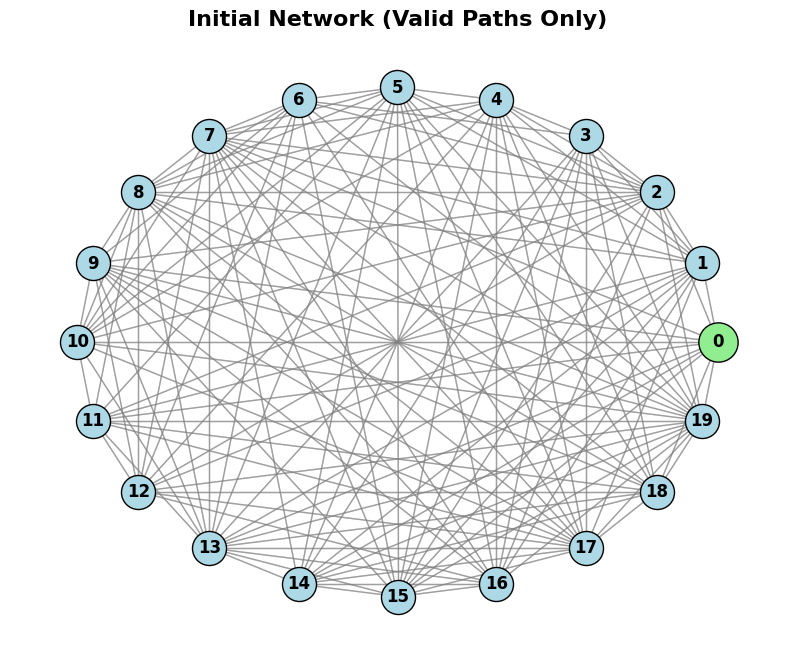

In [31]:
# Shows all possible paths, but blocked paths (INF_INT) will not be drawn
visualize_route(C_list[0], INF, n, route=None, title="Initial Network (Valid Paths Only)")

# 6. Méthode de résolution
 
## 6.1 Positionnement sur les graphes complets
 
Notre problème est défini sur un graphe potentiellement incomplet : certaines arêtes sont bloquées ($C_{ij}^k = +\infty$), ce qui rend le graphe sous-jacent non complet en général.
 
Cependant, certains algorithmes de résolution sont conçus pour opérer sur un graphe complet pondéré, où toute paire de sommets est reliée par une arête de coût fini. Ce choix est justifié par les raisons suivantes :
 
- Généralité de la modélisation : Les arêtes bloquées sont représentées par un coût $+\infty$, ce qui les rend inaccessibles lors de la construction des solutions. Le graphe reste techniquement complet, mais les arêtes bloquées ne sont jamais empruntées car elles ne peuvent pas réduire le coût total.
- Robustesse algorithmique : Travailler sur un graphe complet simplifie la structure des algorithmes, sans perte de généralité puisque les contraintes de blocage sont intégralement encodées dans les matrices de coût.

Ainsi, le positionnement sur un graphe complet est une abstraction de modélisation, et non une simplification du problème réel.
 


## 6.2 Plan d'expérience


### Objectif
Le plan d’expérience vise à comparer différentes solutions sur une même instance dynamique, puis à mesurer :
1. La qualité des solutions (coût),
2. La vitesse de convergence,
3. La robustesse (variabilité inter-runs),
4. L’écart à la borne inférieure issue de la relaxation continue.

### Protocole général
- Choix des métaheuristiques à tester
- Test des métaheuristiques choisies avec des paramètres quelconques
- Test de l'impact des paramètres des métaheuristiques
- Test de l'impact des paramètres d'instances
- Résultat sur notre problème une fois les paramètres optimisés

### Phase 1 : Calibrage des hyperparamètres (OFAT)
Méthode One-Factor-At-A-Time avec compromis coût/temps :

- **GA** :
  - Paramètres testés : `pop_size`, `mutation_rate`, `elite_size`
  - Graines de tuning : `SEEDS_TUNE = [42, 99, 137]`
  - Générations de tuning : `GEN_SEARCH = 200`

- **ACO** :
  - Paramètres testés : `num_ants`, `alpha`, `beta`, `evaporation_rate`
  - Graines de tuning : `SEEDS_TUNE = [42, 99, 137]`
  - Itérations de tuning : `ITER_SEARCH = 100`

Le meilleur réglage est choisi via un score de compromis (normalisation coût + durée).

#### Critère de sélection des hyperparamètres

Afin d’identifier le meilleur compromis entre qualité de solution et temps de calcul, nous définissons un score agrégé basé sur une normalisation des deux critères.

Pour chaque configuration testée, on note :
- C : le coût moyen de la solution,
- T: le temps moyen de convergence.

Ces deux mesures étant de nature différente, elles sont ramenées sur une même échelle via une normalisation min-max :

$$
C_{\text{norm}} = \frac{C - C_{\min}}{C_{\max} - C_{\min}}, \quad
T_{\text{norm}} = \frac{T - T_{\min}}{T_{\max} - T_{\min}}
$$

En cas d’absence de variance ($( C_{\max} = C_{\min} )$ ou $(T_{\max} = T_{\min})$), le terme normalisé correspondant est fixé à 0, afin de ne pas introduire de biais numérique.

Le score global est ensuite défini comme une combinaison linéaire :

$$
\text{score} = \lambda \cdot C_{\text{norm}} + (1 - \lambda) \cdot T_{\text{norm}}
$$

où $\lambda \in [0,1]$ contrôle l’importance relative accordée à la qualité de solution par rapport au temps de calcul.

Dans notre étude, nous choisissons $\lambda = 0.5$, ce qui correspond à un compromis équilibré entre performance et rapidité. Ce choix est cohérent avec l’objectif de comparer des métaheuristiques dans un cadre où les deux dimensions sont jugées également importantes.

La configuration retenue est celle minimisant ce score.

### Phase 2 : Validation des meilleurs paramètres
Évaluation des paramètres retenus sur des graines non utilisées en tuning :

- SEEDS_FINAL = `[42, 99, 137, 201, 314]`
- GA : `GEN_FINAL = 500`
- ACO : `ITER_FINAL = 300`

Statistiques reportées : moyenne, minimum, écart-type des coûts + courbes de convergence.

### Phase 3 : Sensibilité aux paramètres d’instance
Étude séparée de l’impact de :
1. \(K\) : nombre de matrices dynamiques,
2. \(p_{blocage}\) : probabilité de blocage des arêtes,
3. \(n\) : nombre de sommets.

Protocole :
- `NB_RUNS = 10` par configuration,
- Instance régénérée à chaque run,
- Filtrage des graphes non connexes,
- Suivi du coût moyen et du temps de convergence (avec dispersion).

### Phase 4 : Robustesse (100 runs)
Pour chaque métaheuristique :
- 100 exécutions avec les meilleurs paramètres,
- Extraction de la meilleure tournée globale,
- Distribution des coûts obtenus.

Puis calcul de l’écart relatif à la borne inférieure :
$$
\text{écart}(\%) = \frac{\text{coût} - \text{borne inférieure}}{\text{borne inférieure}} \times 100
$$
et visualisation par histogramme avec repères moyenne et médiane.

### Indicateurs finaux
- Qualité : coût moyen / min / std
- Vitesse : temps moyen de convergence
- Robustesse : variance inter-runs
- Référence théorique : écart à la borne inférieure relaxée

## 6.3 Relaxation continue et borne inférieure
### Principe de la relaxation continue

Les algorithmes génétique (GA) et colonie de fourmis (ACO) produisent
des solutions réalisables du problème de tournée.

Cependant, comme le problème est NP-difficile, nous ne pouvons pas prouver que ces algorithmes retournent l'optimum global.

On introduit donc une relaxation continue du modèle.

Elle consiste à supprimer la contrainte d’intégralité des variables :

- Modèle original

$$
X_{ij}^k \in \mathbb{N}
$$

- Modèle relaxé

$$
X_{ij}^k \ge 0, \qquad X_{ij}^k \in \mathbb{R}
$$

Dans ce modèle relaxé, les déplacements deviennent fractionnaires. Par exemple :
$$
X_{AB}=0.25
$$

signifie mathématiquement que seulement 25 % du déplacement $A \rightarrow B$ est effectué.

Cette situation n’a pas de sens physique, mais elle permet :

- De transformer le problème combinatoire en problème continu,
- D’obtenir une solution beaucoup plus facile à calculer.

### Borne inférieure

La relaxation autorise davantage de liberté que le problème réel. Dans notre cas, nous cherchons à minimiser notre fonction objectif, ainsi, le resultat de notre relaxation ne peut donc jamais coûter plus cher que la solution optimale réelle :

$$
\text{Coût relaxation} \le \text{Coût optimal réel}
$$

La valeur obtenue constitue une borne inférieure.

Elle représente le coût minimal théorique atteignable lorsque les contraintes discrètes n’existent pas.

La relaxation n'a pas pour but de fournir une tournée réalisable, mais une référence mathématique.

### Formulation mathématique relaxée

#### Variables

$$
x_{ij}^k \ge 0
$$

variables réelles représentant un flux fractionnaire.

#### Fonction objectif

L’objectif consiste à minimiser le coût total de déplacement :

$$
\min \sum_{k} \sum_{i} \sum_{j} C_{ij}^k \, x_{ij}^k
$$

où $C_{ij}^k$ désigne le coût pour aller de la ville $i$ vers la ville $j$ au temps $k$.

#### Contraintes

1. Conservation du flux : Chaque ville conserve le même flux entrant et sortant :

$$
\sum_{j,k} x_{ij}^k
=
\sum_{j,k} x_{ji}^k
$$

2. Visite minimale : Chaque ville doit être atteinte au moins une fois :

$$
\sum_{j,k} x_{ij}^k \ge 1
$$


### Implémentation Python (PuLP)

In [32]:
def relaxation_continue_time_expanded(C_list, n, K):    
    T = n                   # Nombre d'étapes exactes pour un tour (n arêtes)

    # Création du problème d'optimisation
    prob = LpProblem("Relaxation_Temps_Etendu", LpMinimize)

    # Variables continues x[i, j, t] : fraction du trajet de i vers j à l'étape t
    x = {}
    
    for t in range(1, T + 1):
        # Indice de la matrice C^k active à l'étape t (0-indexé pour la liste)
        k_idx = (t - 1) % K
        
        for i in range(n):
            for j in range(n):
                # Pas de boucles sur place et la route ne doit pas être bloquée
                if i != j and C_list[k_idx][i][j] < INF:
                    
                    # Règle stricte 1 : Interdit de revenir au dépôt avant la toute dernière étape (T)
                    if j == 0 and t < T:
                        continue
                    
                    # Règle stricte 2 : Interdit de quitter le dépôt après l'étape 1
                    if i == 0 and t > 1:
                        continue
                        
                    x[i, j, t] = LpVariable(f"x_{i}_{j}_t{t}", lowBound=0)

    # Fonction objectif : Coût dynamique exact à l'étape t
    prob += lpSum(C_list[(t - 1) % K][i][j] * x[i, j, t] for (i, j, t) in x)

    # C1 : Le véhicule (100% du flux) quitte le dépôt à l'étape 1
    prob += lpSum(x[0, j, 1] for j in range(1, n) if (0, j, 1) in x) == 1, "Depart_Depot"

    # C2 : Continuité stricte du temps (Conservation du flux)
    # "Si une fraction du camion arrive en j à l'étape t, elle DOIT repartir de j à l'étape t+1"
    for t in range(1, T):
        for j in range(1, n): # Pour toutes les villes sauf le dépôt
            flux_entrant = lpSum(x[i, j, t] for i in range(n) if (i, j, t) in x)
            flux_sortant = lpSum(x[j, l, t + 1] for l in range(n) if (j, l, t + 1) in x)
            prob += (flux_entrant == flux_sortant, f"Continuite_{j}_etape_{t}")

    # C3 : Chaque ville doit être visitée au moins une fois (sauf le dépôt)
    for j in range(1, n):
        prob += lpSum(x[i, j, t] for (i, dest, t) in x if dest == j) >= 1, f"Visite_{j}"

    # C4 : Le véhicule rentre au dépôt à l'étape T
    prob += lpSum(x[i, 0, T] for i in range(1, n) if (i, 0, T) in x) == 1, "Retour_Depot"

    # Résolution (msg=False permet de masquer les logs de l'algorithme)
    prob.solve(PULP_CBC_CMD(msg=False))

    if LpStatus[prob.status] == "Optimal":
        return value(prob.objective)

    return None

# Lancement du calcul
borne_inf_reelle = relaxation_continue_time_expanded(C_list, n, K)
print("Borne inférieure (Time-Expanded) :", borne_inf_reelle)

Borne inférieure (Time-Expanded) : 831.1818172909999


## 6.4 Choix des méthodes de résolution
 
Notre problème est NP-difficile. Cela signifie qu'il n'existe, à ce jour, aucun algorithme exact capable de le résoudre en temps polynomial. Les approches exactes (comme la force brute ou la programmation linéaire en nombres entiers) deviennent rapidement inapplicables dès que la taille du graphe augmente.
 
Pour cette raison, nous optons pour des métaheuristiques, c'est-à-dire des méthodes approchées capables de produire des solutions de bonne qualité en temps raisonnable, sans garantie d'optimalité. Nous avons retenu deux approches complémentaires :
 
| Méthode | Paradigme | Avantage principal |
|---|---|---|
| Algorithme génétique (GA) | Évolution d'une population | Exploration large de l'espace de solutions |
| Colonie de fourmis (ACO) | Apprentissage collectif | Exploitation des meilleures trajectoires passées |
 
Ces deux algorithmes sont particulièrement adaptés aux problèmes de type TSP. Leur combinaison permet de comparer deux philosophies d'exploration différentes sur une même instance, et d'évaluer la robustesse des solutions obtenues.

## 6.4.1 Colonie de fourmis (ACO)
### Principe général
 
L'algorithme de colonie de fourmis (Ant Colony Optimization) est inspiré du comportement des fourmis réelles qui, en cherchant de la nourriture, déposent des phéromones sur les chemins empruntés. Les fourmis suivantes sont attirées par les chemins les plus phéromonés, ce qui renforce les bonnes solutions et fait émerger collectivement un chemin optimal.
 
### Construction d'une solution
 
Chaque fourmi construit une tournée en partant du dépôt $v_0$ et en choisissant à chaque étape $k$ la prochaine ville selon une probabilité proportionnelle à deux facteurs :
 
$$P(j \mid i, k) = \frac{\tau_{ij}^{\alpha} \times \eta_{ij}^{\beta}}{\sum_{l \in \mathcal{N}} \tau_{il}^{\alpha} \times \eta_{il}^{\beta}}$$
 
où :
- $\tau_{ij}$ : intensité de phéromone sur l'arête $\{i,j\}$
- $\eta_{ij} = \frac{1}{C_{ij}^k}$ : visibilité (inverse du coût, au pas $k$)
- $\alpha$ : poids accordé aux phéromones (exploitation des bonnes solutions passées)
- $\beta$ : poids accordé à la visibilité (heuristique gloutonne locale)
- $\mathcal{N}$ : ensemble des villes accessibles depuis $i$ au pas $k$ (arêtes non bloquées)
Les villes non encore visitées sont **prioritaires** lors du choix. Si aucune ville non visitée n'est accessible, la fourmi peut revenir sur ses pas.
 
### Mise à jour des phéromones
 
À la fin de chaque itération, les phéromones sont mises à jour en deux étapes :
 
1. Évaporation : toutes les phéromones sont réduites d'un facteur $(1 - \rho)$ pour éviter la convergence prématurée :
$$\tau_{ij} \leftarrow (1 - \rho) \times \tau_{ij}$$
 
2. Dépôt : chaque fourmi ayant trouvé une solution admissible dépose une quantité de phéromone inversement proportionnelle au coût de sa tournée :
$$\tau_{ij} \leftarrow \tau_{ij} + \frac{Q}{\text{coût de la tournée}}$$
 
Le dépôt est symétrique (sur $\tau_{ij}$ et $\tau_{ji}$) car le graphe est non orienté.
 
### Adaptations au problème dynamique
 
Contrairement au TSP classique, notre problème présente des coûts variant à chaque déplacement. L'heuristique $\eta_{ij} = \frac {1}{C_{ij}^k}$ est donc réévaluée à chaque pas $k$, en utilisant la matrice active $C^k$, ce qui permet aux fourmis de tenir compte de la dynamique du réseau lors de la construction de la tournée.

[Aller à ACO](#7-implementation-du-aco)

## 6.4.2 Algorithme génétique (GA)
 
### Principe général
 
Un algorithme génétique modélise l'évolution d'une population de solutions candidates au fil des générations. À chaque génération, les meilleures solutions sont sélectionnées, croisées entre elles pour produire de nouveaux individus, puis mutées aléatoirement. Ce processus itératif imite la sélection naturelle darwinienne et tend à faire converger la population vers des solutions de bonne qualité.
 
### Représentation d'une solution
 
Une solution (ou individu) est représentée par une liste ordonnée de villes à visiter, excluant le dépôt $v_0$ (point de départ et d'arrivée implicite). Par exemple, pour 4 villes :
 
$$\text{Route} = [3, 1, 4, 2] \implies \text{Tournée} : v_0 \to 3 \to 1 \to 4 \to 2 \to v_0$$

La longueur d'une route est bornée par $\text{max\_steps} - 1$ (le dernier pas étant réservé au retour au dépôt), ce qui autorise des routes de longueur variable et admet les revisites.
 
### Fonction d'évaluation (fitness)
 
Le coût d'une tournée est calculé en tenant compte de la dynamique des matrices de coût. À chaque déplacement, la matrice active est $C^k$ avec $k$ incrémenté cycliquement.
 
### Population initiale
 
La population initiale est générée par une heuristique de plus proche voisin (nearest neighbor) sur le graphe défini par $C^1$ (état initial, avec blocages). Pour chaque individu, l'ordre des villes candidates est d'abord permuté aléatoirement afin d'introduire de la diversité entre les solutions, puis la tournée est construite pas à pas en choisissant à chaque étape la ville non visitée la plus proche parmi les voisins accessibles. Si le graphe est trop incomplet pour qu'une telle construction aboutisse, on recourt en dernier ressort à des permutations aléatoires des villes. Cette stratégie garantit des solutions admissibles et de bonne qualité dès l'initialisation.
 
### Sélection
 
La sélection se fait par tournoi : à chaque tour, $k$ individus sont tirés aléatoirement dans la population, et le meilleur (de plus faible coût) est retenu comme parent. Ce mécanisme favorise les bonnes solutions tout en maintenant une diversité suffisante.
 
### Croisement
 
L'opérateur de croisement combine deux parents $p_1$ et $p_2$ en concaténant un préfixe de $p_1$ avec un suffixe de $p_2$, les points de coupure étant choisis aléatoirement. Les villes absentes de l'enfant sont ensuite réinsérées à la première position faisable (c'est-à-dire respectant les contraintes d'accessibilité du graphe), afin de garantir que toutes les villes sont bien visitées au moins une fois. La longueur de l'enfant est tronquée si nécessaire pour ne pas dépasser $\texttt{max\_steps} - 1$.
 
### Mutation
 
Trois types de mutation sont appliqués aléatoirement, chacun avec probabilité $1/3$ :
 
| Type | Description | Rôle |
|---|---|---|
| Inversion de segment (2-opt) | Renverse l'ordre des villes entre deux indices $i < j$ | Explore des réarrangements locaux de la tournée |
| Insertion | Insère une ville aléatoire à une position aléatoire (sous réserve que la longueur reste inférieure à $\texttt{max\_steps} - 1$) | Permet les revisites et perturbe la structure globale |
| Suppression de revisite | Supprime une occurrence d'une ville visitée plus d'une fois | Réduit les redondances et améliore le coût |
 
Ces mutations permettent d'équilibrer exploration (nouvelles configurations) et exploitation (amélioration locale).
 
### Élitisme
 
À chaque génération, les `elite_size` meilleures solutions sont conservées sans modification dans la nouvelle population. Cela garantit que la qualité de la meilleure solution ne régresse jamais au fil des générations.

# 7. Implémentation du GA

In [33]:
# Fonction de fitness : calcule le coût total d'une route donnée en tenant compte des matrices de coût dynamiques
def tsp_fitness(route, C_list, K):
    cost = 0
    k = 1
    current = 0
    for city in route:
        Ck = get_Ck(C_list, K, k)
        cost += Ck[current][city]
        current = city
        k += 1
    Ck = get_Ck(C_list, K, k)
    cost += Ck[current][0]
    return cost


# Nearest-neighbor adapté au multi-visite : on cherche le voisin le plus proche à chaque étape, mais on autorise les revisites pour éviter les blocages
def nearest_neighbor_route(C_list, n, rng, INF):
    C1 = C_list[0]
    unvisited = list(range(1, n))
    rng.shuffle(unvisited)          # dépôt de départ aléatoire pour la diversité
    route = []
    current = 0

    while unvisited:
        # Cherche le voisin non-visité le plus proche accessible
        reachable = [(C1[current][j], j) for j in unvisited if C1[current][j] < INF]
        if not reachable:
            return None             # graphe non connexe
        _, next_city = min(reachable)
        route.append(next_city)
        unvisited.remove(next_city)
        current = next_city

    if C1[current][0] >= INF:      # retour au dépôt impossible
        return None
    return route


# Initialisation de la population : on génère des routes par nearest-neighbor, puis on complète aléatoirement si nécessaire
def init_population(C_list, n, pop_size, rng, INF):
    population = []

    for _ in range(pop_size * 20):
        route = nearest_neighbor_route(C_list, n, rng, INF)
        if route is not None and len(route) > 0:
            population.append(route)
        if len(population) == pop_size:
            return population

    if len(population) == 0:
        population = [
            list(rng.permutation(range(1, n)))
            for _ in range(pop_size)
        ]
        return population

    while len(population) < pop_size:
        population.append(rng.choice(population).copy())

    return population


# Sélection par tournoi : on choisit k individus au hasard et on prend le meilleur parmi eux
def selection(population, fitnesses, k, rng):
    if len(population) == 0:
        raise ValueError("Population vide dans selection")

    k = min(k, len(population))
    idx = rng.choice(len(population), k, replace=False)
    best = min(idx, key=lambda i: fitnesses[i])
    return population[best]


# Crossover : on prend un segment de parent1 et on complète avec les villes de parent2, en insérant les villes manquantes au meilleur endroit possible
# NOTE : la longueur du child est bornée par max_steps - 1 (le +1 étant le retour au dépôt)
def crossover(parent1, parent2, n, C1, rng, INF, max_steps):
    if len(parent1) == 0:
        return parent2.copy()
    if len(parent2) == 0:
        return parent1.copy()
    cut1 = int(rng.integers(1, max(2, len(parent1))))
    cut2 = int(rng.integers(0, max(1, len(parent2))))

    child = list(parent1[:cut1]) + list(parent2[cut2:])
    if len(child) == 0:
        child = parent1.copy()

    # Borne la taille du child pour respecter max_steps (retour au dépôt inclus)
    max_len = max_steps - 1
    if len(child) > max_len:
        child = child[:max_len]

    # On insère uniquement les villes ABSENTES (0 occurrences), tant qu'il reste de la place
    present = set(child)
    missing = set(range(1, n)) - present
    for city in missing:
        if len(child) >= max_len:
            break                      # plus de place disponible
        inserted = False
        for pos in range(len(child) + 1):
            prev = child[pos - 1] if pos > 0 else 0
            nxt  = child[pos]     if pos < len(child) else 0
            if C1[prev][city] < INF and C1[city][nxt] < INF:
                child.insert(pos, city)
                inserted = True
                break
        if not inserted:
            child.append(city)

    return child


# Mutations diverses : inversion de segment, insertion aléatoire (exploration des revisites), suppression de revisite
# NOTE : l'insertion n'est autorisée que si la route reste sous max_steps - 1
def mutate(route, n, rng, max_steps):
    if len(route) == 0:
        return [0]
    route = list(route)
    max_len = max_steps - 1
    mutation_type = int(rng.integers(0, 3))

    if mutation_type == 0 and len(route) >= 2:
        # Inversion de segment (2-opt) — ne change pas la longueur
        i, j = sorted(rng.integers(0, len(route), size=2))
        route[i:j + 1] = route[i:j + 1][::-1]

    elif mutation_type == 1 and len(route) < max_len:
        # Insert une ville aléatoire : explore les revisites (borné par max_steps)
        city = int(rng.integers(1, n))
        pos = int(rng.integers(0, len(route) + 1))
        route.insert(pos, city)

    elif mutation_type == 2:
        # Supprime une revisite si la ville apparaît plusieurs fois
        counts = {}
        for c in route:
            counts[c] = counts.get(c, 0) + 1
        duplicates = [c for c, cnt in counts.items() if cnt > 1]
        if duplicates:
            city_to_remove = int(rng.choice(duplicates))
            positions = [i for i, c in enumerate(route) if c == city_to_remove]
            route.pop(int(rng.choice(positions)))

    # Garde-fou final : si par un chemin quelconque la route dépasse, on tronque
    if len(route) > max_len:
        route = route[:max_len]

    return route


# Algorithme génétique principal
def run_genetic_tsp(C_list, max_steps, pop_size, generations, mutation_rate, elite_size, rng, INF, n, K):

    population = init_population(C_list, n, pop_size, rng, INF)
    if len(population) == 0:
        raise ValueError("Population initiale vide")

    # Sécurité : on tronque les individus initiaux si jamais ils dépassent max_steps
    max_len = max_steps - 1
    population = [ind[:max_len] if len(ind) > max_len else ind for ind in population]

    best_solution = None
    best_cost = INF
    history = []
    t_start = time.perf_counter()
    t_converge = 0.0

    for gen in range(generations):
        fitnesses = [tsp_fitness(ind, C_list, K) for ind in population]

        gen_best_idx = int(np.argmin(fitnesses))
        if fitnesses[gen_best_idx] < best_cost:
            best_cost = fitnesses[gen_best_idx]
            best_solution = list(population[gen_best_idx])
            t_converge = time.perf_counter() - t_start  # mis à jour à chaque amélioration

        history.append(best_cost if best_cost != INF else None)

        elite_indices = np.argsort(fitnesses)[:elite_size]
        new_population = [list(population[i]) for i in elite_indices]

        while len(new_population) < pop_size:
            p1 = selection(population, fitnesses, 5, rng)
            p2 = selection(population, fitnesses, 5, rng)
            child = crossover(p1, p2, n, C_list[0], rng, INF, max_steps)

            if rng.random() < mutation_rate:
                child = mutate(child, n, rng, max_steps)

            new_population.append(child)

        population = new_population

    return best_solution, best_cost, history, t_converge

Affichage des résultats

In [34]:
# Affichage détaillé de la route finale avec les coûts à chaque étape
def display_route_details(C_list, K, route):
    """
    Crée un tableau qui suit EXACTEMENT la logique de temps 'k' de la fourmi
    en appelant get_Ck.
    """
    if not route:
        print("Aucune route valide à afficher.")
        return

    clean_route = [city for city in route if city != 0]
    
    full_route = [0] + clean_route + [0]
    # ----------------------------

    details = []
    total_cost = 0
    
    # On boucle sur la route complète (full_route)
    for i in range(len(full_route) - 1):
        u = full_route[i]
        v = full_route[i+1]
        
        # L'horloge (k commence à 1 à la première étape)
        k = i + 1 
        
        # On utilise la même fonction que l'algorithme pour récupérer C^k
        Ck = get_Ck(C_list, K, k) 
        
        # On récupère le coût
        step_cost = int(Ck[u][v]) 
        total_cost += step_cost
        
        details.append({
            "Étape": i + 1,
            "Temps (k)": k,
            "Départ": f"Ville {u}",
            "Arrivée": f"Ville {v}",
            "Coût": step_cost
        })
    
    df = pd.DataFrame(details)
    
    display(HTML("<h3>Détail des coûts de la tournée (Synchronisé)</h3>"))
    display(df)
    
    if total_cost >= INF:
        display(HTML(f"<h4 style='color:red;'><b>Coût Total Vérifié : {total_cost} (INVALIDE : ROUTE BLOQUÉE)</b></h4>"))
    else:
        display(HTML(f"<h4 style='color:green;'><b>Coût Total Vérifié : {total_cost}</b></h4>"))

Test de plusieurs paramètres paramètres

In [35]:
# Définition des scénarios pour l'Algorithme Génétique
ga_scenarios = {
    "Standard":       {"pop": 100, "mut": 0.25, "elite": 10},
    "Forte Mutation": {"pop": 100, "mut": 0.80, "elite": 10},
    "Grosse Pop.":    {"pop": 500, "mut": 0.25, "elite": 20},
    "Élitisme ++":    {"pop": 100, "mut": 0.25, "elite": 40}
}

# Variables pour sauvegarder le record ABSOLU du GA
global_best_route_ga = None
global_best_cost_ga = INF
global_best_name_ga = ""

ga_results_history = {}
Iteration_max_ga = 300

print("Démarrage des expériences Algorithme Génétique...")
for name, params in ga_scenarios.items():
    print(f"Test du scénario: {name}")
    
    # Utilisation de variables temporaires current pour ne pas écraser le record
    current_route, current_cost, history, _convergence_time = run_genetic_tsp(
        C_list, 
        max_steps=MAX_STEPS, 
        pop_size=params["pop"], 
        generations=Iteration_max_ga, 
        mutation_rate=params["mut"], 
        elite_size=params["elite"],
        rng=rng,
        INF=INF,
        n=n,
        K=K
    )
    
    ga_results_history[name] = history
    print(f"-> Coût final {name} : {current_cost}")

    # MISE À JOUR DU RECORD GÉNÉTIQUE
    if current_cost < global_best_cost_ga:
        global_best_cost_ga = current_cost
        global_best_route_ga = list(current_route)
        global_best_name_ga = name

global_random_cost_ga = global_best_cost_ga

print("\n" + "="*50)
print(f"MEILLEUR GA : {global_best_name_ga} (Coût: {global_best_cost_ga})")
print("="*50)

Démarrage des expériences Algorithme Génétique...
Test du scénario: Standard
-> Coût final Standard : 1434.0
Test du scénario: Forte Mutation
-> Coût final Forte Mutation : 1594.0
Test du scénario: Grosse Pop.
-> Coût final Grosse Pop. : 1396.0
Test du scénario: Élitisme ++
-> Coût final Élitisme ++ : 1745.0

MEILLEUR GA : Grosse Pop. (Coût: 1396.0)


Affichage du graph de la meilleure solution.

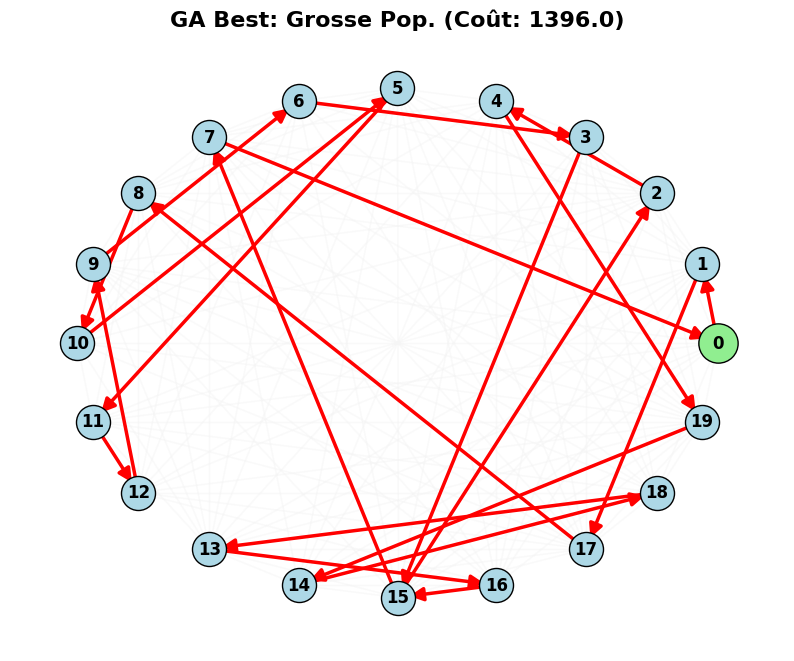

,Étape,Temps (k),Départ,Arrivée,Coût
0,1,1,Ville 0,Ville 1,47
1,2,2,Ville 1,Ville 17,87
2,3,3,Ville 17,Ville 8,59
3,4,4,Ville 8,Ville 10,13
4,5,5,Ville 10,Ville 5,76
5,6,6,Ville 5,Ville 11,47
6,7,7,Ville 11,Ville 12,53
7,8,8,Ville 12,Ville 9,140
8,9,9,Ville 9,Ville 6,135
9,10,10,Ville 6,Ville 3,145


In [36]:
# Afficher le graphe du record GA
visualize_route(
    C_list[0], 
    INF,
    n,
    route=global_best_route_ga, 
    title=f"GA Best: {global_best_name_ga} (Coût: {global_best_cost_ga})"
)

# Afficher le tableau détaillé synchronisé
# On utilise global_best_route_ga pour avoir les bons coûts par étape k
display_route_details(C_list, K, route=global_best_route_ga)

Convergence selon nos jeux de paramètres

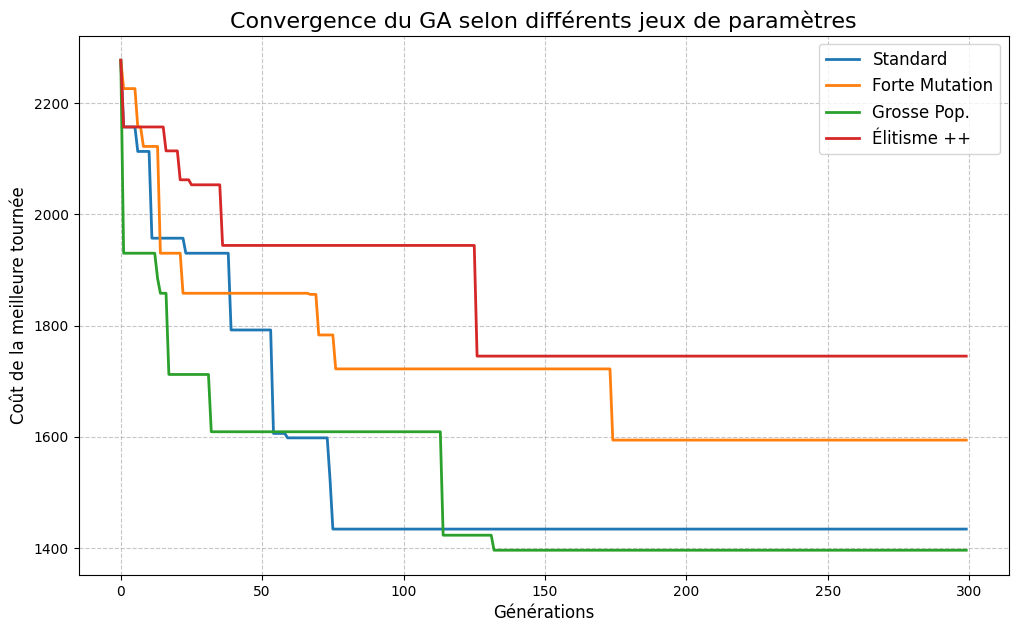

In [37]:
plt.figure(figsize=(12, 7))

for name, history in ga_results_history.items():
    # Remplacement des valeurs infinies initiales pour que le graphique soit lisible
    clean_history = [h if h is not None else max([x for x in history if x is not None]) for h in history]
    plt.plot(clean_history, label=name, linewidth=2)

plt.title("Convergence du GA selon différents jeux de paramètres", fontsize=16)
plt.xlabel("Générations", fontsize=12)
plt.ylabel("Coût de la meilleure tournée", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
# On utilise une échelle logarithmique si les écarts initiaux sont énormes
# plt.yscale('log') 
plt.show()

# Étude expérimentale : Impact des paramètres d'algorithmes

Initial params: {'pop_size': 500, 'mutation_rate': 0.5, 'elite_size': 50}
Best pop_size: 450.0


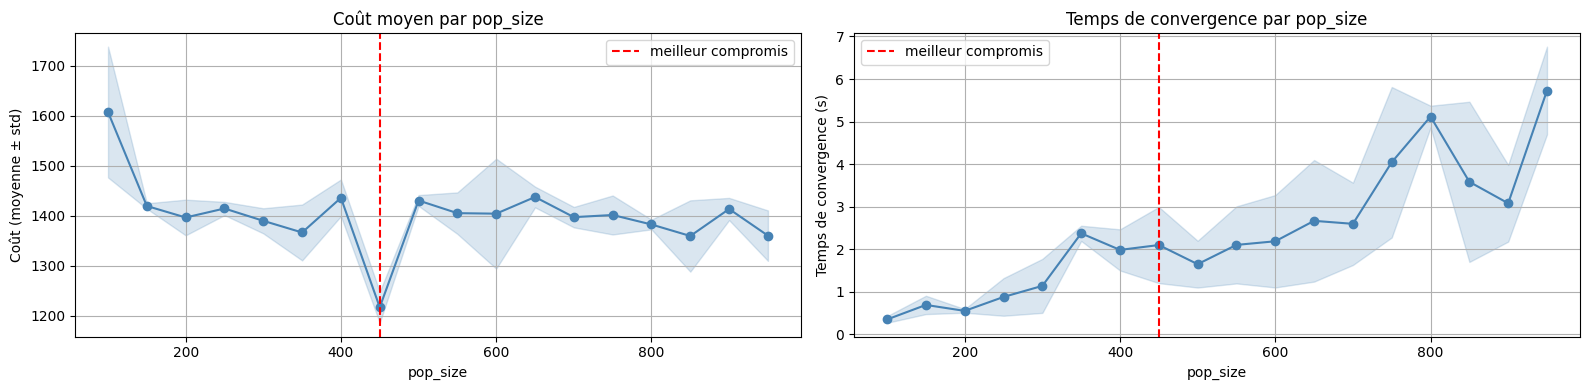

Best mutation_rate: 0.5


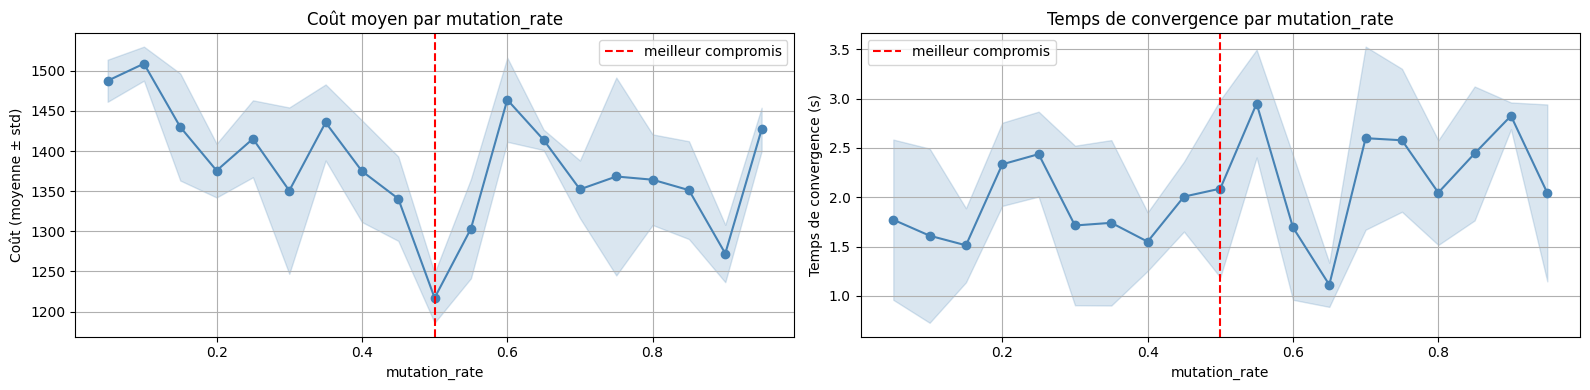


Best params (OFAT): {'pop_size': 450, 'mutation_rate': 0.5, 'elite_size': 50}


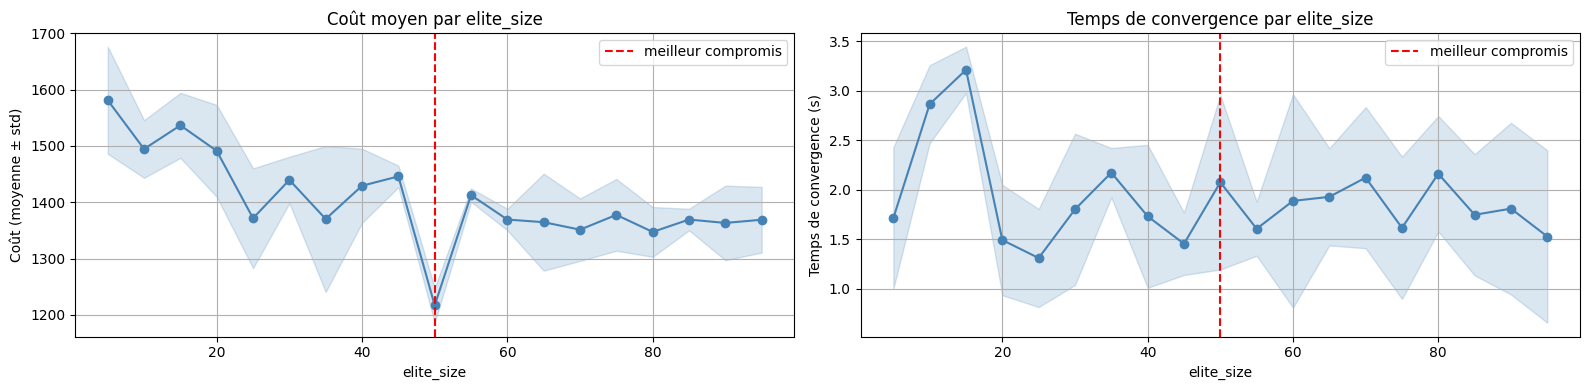


Validation :
Mean : 1227.8
Min  : 1145.0
Std  : 75.56560063944441


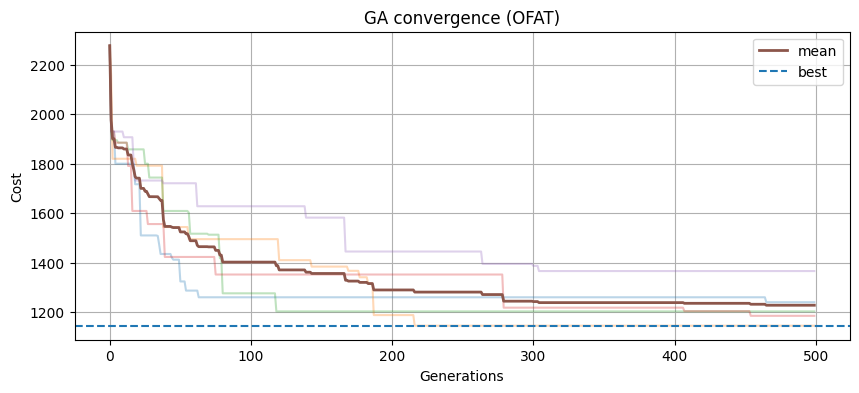

In [38]:

# Configuration de base pour le tuning
SEEDS_TUNE  = [42, 99, 137]
SEEDS_FINAL = [42, 99, 137, 201, 314]

GEN_SEARCH = 200
GEN_FINAL  = 500

# Range de paramètres à tester
pop_sizes =  np.arange(50, 1000, 50)
mutation_rates = np.arange(0.05, 1, 0.05)
elite_sizes = np.arange(5, 100, 5)

# Fonction d'évaluation : exécute le GA avec les paramètres donnés sur plusieurs seeds et retourne les statistiques de coût et de durée
def evaluate(params, generations, seeds):
    costs, durations = [], []
    for s in seeds:
        rng = np.random.default_rng(s)
        _, cost, _, t_conv = run_genetic_tsp(
            C_list,
            max_steps=MAX_STEPS,
            pop_size=params["pop_size"],
            generations=generations,
            mutation_rate=params["mutation_rate"],
            elite_size=params["elite_size"],
            rng=rng, INF=INF, n=n, K=K
        )
        durations.append(t_conv)
        if cost < INF:
            costs.append(cost)
    if not costs:
        return float("inf"), float("inf"), float("inf"), float("inf")
    return np.mean(costs), np.std(costs), np.mean(durations), np.std(durations)

# Fonction de compromis : normalise les coûts et durées, puis calcule un score combiné pour trouver le meilleur compromis
def best_compromise(df, param_col):
    df = df.copy()
    cmin, cmax = df["mean_cost"].min(), df["mean_cost"].max()
    dmin, dmax = df["mean_dur"].min(), df["mean_dur"].max()
    df["cost_norm"] = (df["mean_cost"] - cmin) / (cmax - cmin) if cmax > cmin else 0
    df["dur_norm"]  = (df["mean_dur"]  - dmin) / (dmax - dmin) if dmax > dmin else 0
    df["score"] = 0.5 * df["cost_norm"] + 0.5 * df["dur_norm"]
    return df.sort_values("score").iloc[0][param_col]


# PHASE 1 : OFAT (One Factor At a Time) pour trouver une bonne configuration de base

best_params = {
    "pop_size": int(pop_sizes[len(pop_sizes)//2]),
    "mutation_rate": float(mutation_rates[len(mutation_rates)//2]),
    "elite_size": int(elite_sizes[len(elite_sizes)//2])
}

print("Initial params:", best_params)


# Optimisation de pop_size
results_pop = []

for pop in pop_sizes:
    params = best_params.copy()
    params["pop_size"] = int(pop)
    if params["elite_size"] >= params["pop_size"]:
        continue
    mean_cost, std_cost, mean_dur, std_dur = evaluate(params, GEN_SEARCH, SEEDS_TUNE)
    results_pop.append((pop, mean_cost, std_cost, mean_dur, std_dur))

df_pop = pd.DataFrame(results_pop, columns=["pop", "mean_cost", "std_cost", "mean_dur", "std_dur"])
best_pop = best_compromise(df_pop, "pop")
best_params["pop_size"] = int(best_pop)
print("Best pop_size:", best_pop)

# Plot pop_size
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
best_idx = (0.5 * (df_pop["mean_cost"] - df_pop["mean_cost"].min()) / (df_pop["mean_cost"].max() - df_pop["mean_cost"].min())
           + 0.5 * (df_pop["mean_dur"]  - df_pop["mean_dur"].min())  / (df_pop["mean_dur"].max()  - df_pop["mean_dur"].min())).argmin()

x = df_pop["pop"].values

axes[0].plot(x, df_pop["mean_cost"], marker="o", color="steelblue")
axes[0].fill_between(x, df_pop["mean_cost"] - df_pop["std_cost"], df_pop["mean_cost"] + df_pop["std_cost"], alpha=0.2, color="steelblue")
axes[0].axvline(df_pop.iloc[best_idx]["pop"], color="red", linestyle="--", label="meilleur compromis")
axes[0].set_title("Coût moyen par pop_size")
axes[0].set_xlabel("pop_size")
axes[0].set_ylabel("Coût (moyenne ± std)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, df_pop["mean_dur"], marker="o", color="steelblue")
axes[1].fill_between(x, df_pop["mean_dur"] - df_pop["std_dur"], df_pop["mean_dur"] + df_pop["std_dur"], alpha=0.2, color="steelblue")
axes[1].axvline(df_pop.iloc[best_idx]["pop"], color="red", linestyle="--", label="meilleur compromis")
axes[1].set_title("Temps de convergence par pop_size")
axes[1].set_xlabel("pop_size")
axes[1].set_ylabel("Temps de convergence (s)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

# Optimisation de mutation_rate
results_mut = []

for mut in mutation_rates:
    params = best_params.copy()
    params["mutation_rate"] = float(mut)
    mean_cost, std_cost, mean_dur, std_dur = evaluate(params, GEN_SEARCH, SEEDS_TUNE)
    results_mut.append((mut, mean_cost, std_cost, mean_dur, std_dur))

df_mut = pd.DataFrame(results_mut, columns=["mut", "mean_cost", "std_cost", "mean_dur", "std_dur"])
best_mut = best_compromise(df_mut, "mut")
best_params["mutation_rate"] = float(best_mut)
print("Best mutation_rate:", best_mut)

# Plot mutation_rate

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
best_idx = (0.5 * (df_mut["mean_cost"] - df_mut["mean_cost"].min()) / (df_mut["mean_cost"].max() - df_mut["mean_cost"].min())
           + 0.5 * (df_mut["mean_dur"]  - df_mut["mean_dur"].min())  / (df_mut["mean_dur"].max()  - df_mut["mean_dur"].min())).argmin()

x = df_mut["mut"].values

axes[0].plot(x, df_mut["mean_cost"], marker="o", color="steelblue")
axes[0].fill_between(x, df_mut["mean_cost"] - df_mut["std_cost"], df_mut["mean_cost"] + df_mut["std_cost"], alpha=0.2, color="steelblue")
axes[0].axvline(df_mut.iloc[best_idx]["mut"], color="red", linestyle="--", label="meilleur compromis")
axes[0].set_title("Coût moyen par mutation_rate")
axes[0].set_xlabel("mutation_rate")
axes[0].set_ylabel("Coût (moyenne ± std)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, df_mut["mean_dur"], marker="o", color="steelblue")
axes[1].fill_between(x, df_mut["mean_dur"] - df_mut["std_dur"], df_mut["mean_dur"] + df_mut["std_dur"], alpha=0.2, color="steelblue")
axes[1].axvline(df_mut.iloc[best_idx]["mut"], color="red", linestyle="--", label="meilleur compromis")
axes[1].set_title("Temps de convergence par mutation_rate")
axes[1].set_xlabel("mutation_rate")
axes[1].set_ylabel("Temps de convergence (s)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


# Optimisation de elite_size 
results_elite = []

for elite in elite_sizes:
    params = best_params.copy()
    params["elite_size"] = int(elite)
    if params["elite_size"] >= params["pop_size"]:
        continue
    mean_cost, std_cost, mean_dur, std_dur = evaluate(params, GEN_SEARCH, SEEDS_TUNE)
    results_elite.append((elite, mean_cost, std_cost, mean_dur, std_dur))

df_elite = pd.DataFrame(results_elite, columns=["elite", "mean_cost", "std_cost", "mean_dur", "std_dur"])
best_elite = best_compromise(df_elite, "elite")
best_params["elite_size"] = int(best_elite)
print("\nBest params (OFAT):", best_params)

# Plot elite_size
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
best_idx = (0.5 * (df_elite["mean_cost"] - df_elite["mean_cost"].min()) / (df_elite["mean_cost"].max() - df_elite["mean_cost"].min())
           + 0.5 * (df_elite["mean_dur"]  - df_elite["mean_dur"].min())  / (df_elite["mean_dur"].max()  - df_elite["mean_dur"].min())).argmin()

x = df_elite["elite"].values

axes[0].plot(x, df_elite["mean_cost"], marker="o", color="steelblue")
axes[0].fill_between(x, df_elite["mean_cost"] - df_elite["std_cost"], df_elite["mean_cost"] + df_elite["std_cost"], alpha=0.2, color="steelblue")
axes[0].axvline(df_elite.iloc[best_idx]["elite"], color="red", linestyle="--", label="meilleur compromis")
axes[0].set_title("Coût moyen par elite_size")
axes[0].set_xlabel("elite_size")
axes[0].set_ylabel("Coût (moyenne ± std)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, df_elite["mean_dur"], marker="o", color="steelblue")
axes[1].fill_between(x, df_elite["mean_dur"] - df_elite["std_dur"], df_elite["mean_dur"] + df_elite["std_dur"], alpha=0.2, color="steelblue")
axes[1].axvline(df_elite.iloc[best_idx]["elite"], color="red", linestyle="--", label="meilleur compromis")
axes[1].set_title("Temps de convergence par elite_size")
axes[1].set_xlabel("elite_size")
axes[1].set_ylabel("Temps de convergence (s)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


# PHASE 2 : Validation finale du GA avec les meilleurs paramètres trouvés sur un plus grand nombre de seeds pour confirmer la robustesse
final_costs = []
histories = []

for s in SEEDS_FINAL:
    rng = np.random.default_rng(s)
    _, cost, hist, _ = run_genetic_tsp(
        C_list,
        max_steps=MAX_STEPS,
        pop_size=best_params["pop_size"],
        generations=GEN_FINAL,
        mutation_rate=best_params["mutation_rate"],
        elite_size=best_params["elite_size"],
        rng=rng, INF=INF, n=n, K=K
    )
    final_costs.append(cost)
    histories.append(hist)

print("\nValidation :")
print("Mean :", np.mean(final_costs))
print("Min  :", np.min(final_costs))
print("Std  :", np.std(final_costs))

# PLOT 
plt.figure(figsize=(10, 4))

for h in histories:
    plt.plot(h, alpha=0.3)

plt.plot(np.mean(histories, axis=0), linewidth=2, label="mean")
plt.axhline(np.min(final_costs), linestyle="--", label="best")

plt.title("GA convergence (OFAT)")
plt.xlabel("Generations")
plt.ylabel("Cost")
plt.legend()
plt.grid()
plt.show()


# Conclusion : Optimisation des Paramètres du GA 

## Résultats principaux

Les meilleurs paramètres obtenus sont :

- Population (pop_size) : 450
- Taux de mutation (mutation_rate) : 0.5
- Élite (elite_size) : 50

Ces valeurs correspondent au meilleur compromis entre :

- Un coût moyen faible (qualité des solutions)
- Une variance modérée (stabilité entre les seeds)
- Un temps de convergence raisonnable

## Analyse
- Population (450)
    
    Une population trop faible limite la diversité et entraîne une convergence prématurée. À l’inverse, une population trop grande améliore légèrement la qualité mais au prix d’un temps de calcul significativement plus élevé. La valeur 450 représente un bon équilibre.
- Mutation (0.5)
    
    Un taux relativement élevé a été sélectionné. Cela suggère que le problème nécessite une exploration importante de l’espace de recherche pour éviter les minima locaux. Des taux plus faibles ont conduit à des solutions moins performantes ou moins robustes.
- Élite (50)
    
    Une élite modérée permet de conserver les meilleures solutions tout en laissant suffisamment de place à la diversité génétique. Une élite trop grande réduit l’exploration, tandis qu’une élite trop faible ralentit la convergence.

## Conclusion générale

Cette étude montre que l’algorithme génétique peut être efficacement calibré via une approche simple comme OFAT. Les paramètres obtenus offrent un bon compromis entre performance et efficacité / diversification et intensification, tout en garantissant une robustesse face à l’aléatoire, ce qui est essentiel dans ce type de métaheuristique.


# Étude expérimentale : Impact des paramètres d’instance

### Objectif de l’étude

Cette étude analyse l’impact des caractéristiques des instances sur la difficulté du problème de tournée de livraison.

L’objectif est d’observer comment la complexité et le temps de convergence varient en fonction des paramètres du réseau, sans modifier l’algorithme de résolution.

### Pourquoi utiliser l’algorithme génétique ?

L’algorithme génétique (GA) est utilisé ici comme instrument d’observation.

Le GA reste fixe et joue le rôle d’un solveur de référence (même population, mêmes opérateurs génétiques, mêmes paramètres d’évolution)

Ainsi, toute variation du temps de convergence provient uniquement de la difficulté de l’instance étudiée. Cela permet d’isoler scientifiquement l’effet des paramètres du problème.

### Paramètres étudiés

Trois caractéristiques des instances sont analysées :

- Nombre de matrices temporelles (variation des coûts au cours du temps)
- Nombre de blocages (routes indisponibles dans le réseau)
- Nombre de sommets

Ces paramètres influencent directement la taille de l’espace de recherche, le nombre de trajets réalisables et la difficulté d’optimisation.

L’impact sur le temps de convergence est étudié à l’aide de statistiques descriptives (moyenne et écart-type, ou médiane et MAD), afin de caractériser la tendance et la variabilité des résultats.


### Impact du nombre de matrice de cout

In [39]:
# Paramètres GA
pop_size = 60
generations = 150
mutation_rate = 0.2
elite_size = 5

NB_RUNS = 10

n_test = 40              # FIXE
p_blocage = 0.2     # FIXE

results_K = []

K_values = range(2, 12)

# Test de l'impact de K sur la performance du GA
for K_test in K_values:
    for run in range(NB_RUNS):
        C_init_Test = gen_nominal_matrix(n_test, rng, INF, 1, 60)
        B_Test = gen_block_matrix(n_test, rng, INF, p_blocage=p_blocage)
        C1_Test = gen_C1_matrix(C_init_Test, B_Test, INF)
        surcost_Test = gen_surcost_matrices(n_test, K_test, B_Test, rng, DELTA)
        C_list_Test = build_all_Ck(C1_Test, surcost_Test)

        if not check_connexe(C_list_Test[0], INF):
            continue

        sol, cost, history, convergence_time = run_genetic_tsp(
            C_list_Test, MAX_STEPS,
            pop_size, generations,
            mutation_rate, elite_size,
            rng, INF, n_test, K_test
        )

        results_K.append({
            "K": K_test,
            "temps_conv": convergence_time,
            "cout": cost
        })

df_K = pd.DataFrame(results_K)

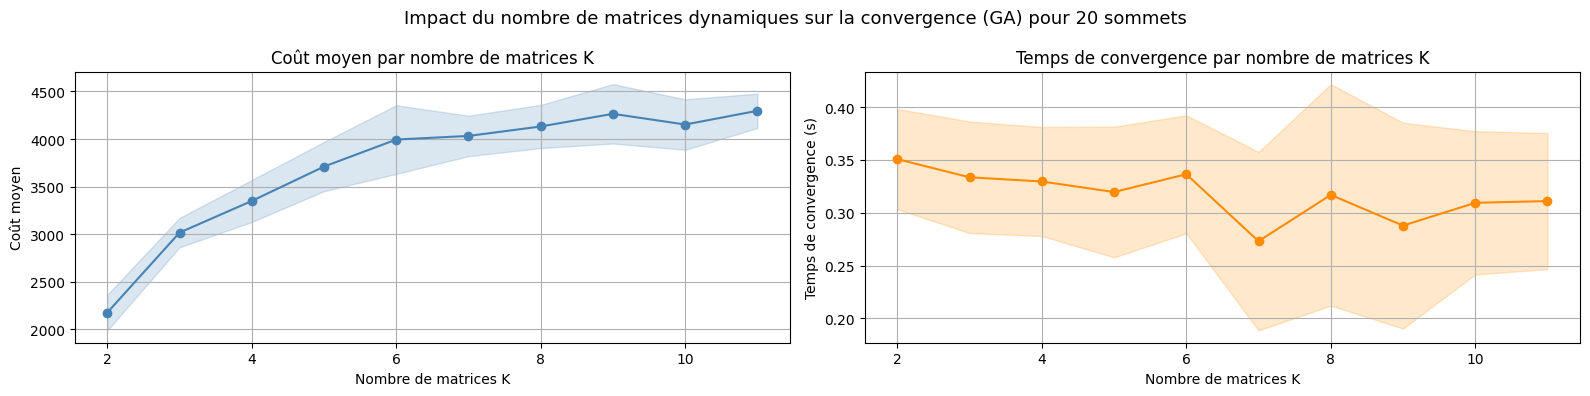

In [40]:
# Calcul des statistiques de coût et de temps de convergence pour chaque K
stats_K = df_K.groupby("K").agg(
    mean_cout=("cout", "mean"),
    std_cout=("cout", "std"),
    mean_conv=("temps_conv", "mean"),
    std_conv=("temps_conv", "std"),
)

x = stats_K.index

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(x, stats_K["mean_cout"], marker="o", color="steelblue")
axes[0].fill_between(x,
    stats_K["mean_cout"] - stats_K["std_cout"],
    stats_K["mean_cout"] + stats_K["std_cout"],
    alpha=0.2, color="steelblue")
axes[0].set_title("Coût moyen par nombre de matrices K")
axes[0].set_xlabel("Nombre de matrices K")
axes[0].set_ylabel("Coût moyen")
axes[0].grid(True)

axes[1].plot(x, stats_K["mean_conv"], marker="o", color="darkorange")
axes[1].fill_between(x,
    stats_K["mean_conv"] - stats_K["std_conv"],
    stats_K["mean_conv"] + stats_K["std_conv"],
    alpha=0.2, color="darkorange")
axes[1].set_title("Temps de convergence par nombre de matrices K")
axes[1].set_xlabel("Nombre de matrices K")
axes[1].set_ylabel("Temps de convergence (s)")
axes[1].grid(True)

plt.suptitle("Impact du nombre de matrices dynamiques sur la convergence (GA) pour " + str(n) + " sommets", fontsize=13)
plt.tight_layout()
plt.show()

### Impact de la probabilité de blocage

In [41]:
K_fixed = 6
n_test = 40

blocage_probs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,
                 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

results_blocage = []

# Test de l'impact du taux de blocage sur la performance du GA
for p_blocage in blocage_probs:
    for run in range(NB_RUNS):
        C_init_Test = gen_nominal_matrix(n_test, rng, INF, 1, 60)
        B_Test = gen_block_matrix(n_test, rng, INF, p_blocage=p_blocage)
        C1_Test = gen_C1_matrix(C_init_Test, B_Test, INF)
        surcost_Test = gen_surcost_matrices(n_test, K_fixed, B_Test, rng, DELTA)
        C_list_Test = build_all_Ck(C1_Test, surcost_Test)

        if not check_connexe(C_list_Test[0], INF):
            continue

        sol, cost, history, convergence_time = run_genetic_tsp(
            C_list_Test, MAX_STEPS,
            pop_size, generations,
            mutation_rate, elite_size,
            rng, INF, n_test, K_fixed
        )

        results_blocage.append({
            "p_blocage": p_blocage,
            "temps_conv": convergence_time,
            "cout": cost
        })

df_blocage = pd.DataFrame(results_blocage)


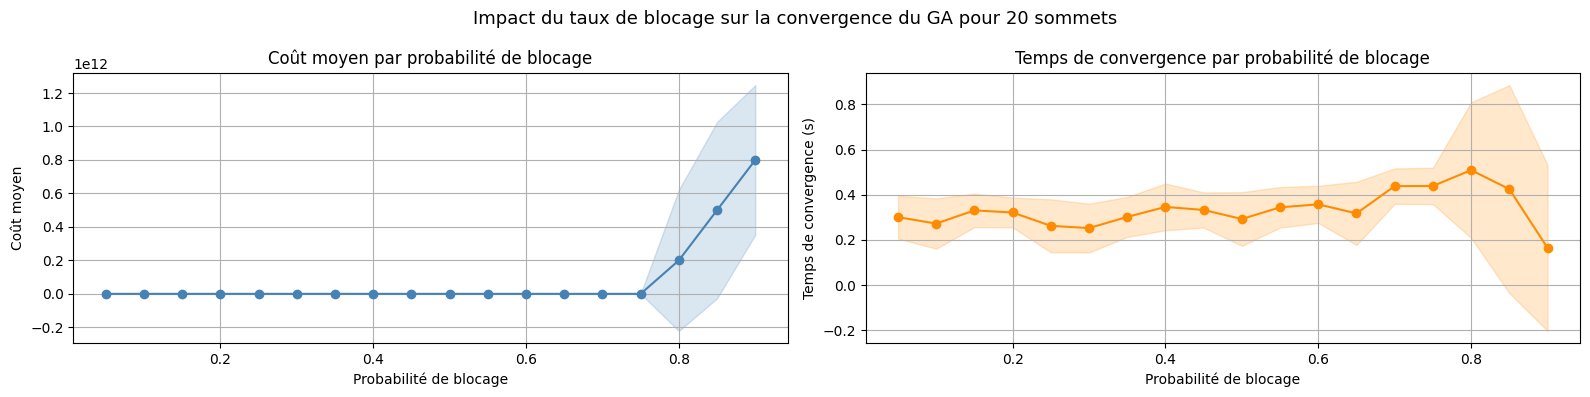

In [42]:
# Calcul des statistiques de coût et de temps de convergence pour chaque taux de blocage
stats_bloc = df_blocage.groupby("p_blocage").agg(
    mean_cout=("cout", "mean"),
    std_cout=("cout", "std"),
    mean_conv=("temps_conv", "mean"),
    std_conv=("temps_conv", "std"),
)

x = stats_bloc.index

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(x, stats_bloc["mean_cout"], marker="o", color="steelblue")
axes[0].fill_between(x,
    stats_bloc["mean_cout"] - stats_bloc["std_cout"],
    stats_bloc["mean_cout"] + stats_bloc["std_cout"],
    alpha=0.2, color="steelblue")
axes[0].set_title("Coût moyen par probabilité de blocage")
axes[0].set_xlabel("Probabilité de blocage")
axes[0].set_ylabel("Coût moyen")
axes[0].grid(True)

axes[1].plot(x, stats_bloc["mean_conv"], marker="o", color="darkorange")
axes[1].fill_between(x,
    stats_bloc["mean_conv"] - stats_bloc["std_conv"],
    stats_bloc["mean_conv"] + stats_bloc["std_conv"],
    alpha=0.2, color="darkorange")
axes[1].set_title("Temps de convergence par probabilité de blocage")
axes[1].set_xlabel("Probabilité de blocage")
axes[1].set_ylabel("Temps de convergence (s)")
axes[1].grid(True)

plt.suptitle("Impact du taux de blocage sur la convergence du GA pour " + str(n) + " sommets", fontsize=13)
plt.tight_layout()
plt.show()


### Impact du nombre de sommets

In [43]:
K_fixed = 6
p_blocage = 0.2
n_values = [20, 30, 40, 50, 60]

results_n = []

# Test de l'impact du nombre de sommets sur la performance du GA
for n_test in n_values:
    for run in range(NB_RUNS):
        C_init_Test = gen_nominal_matrix(n_test, rng, INF, 1, 60)
        B_Test = gen_block_matrix(n_test, rng, INF, p_blocage=p_blocage)
        C1_Test = gen_C1_matrix(C_init_Test, B_Test, INF)
        surcouts_Test = gen_surcost_matrices(n_test, K_fixed, B_Test, rng, DELTA)
        C_list_Test = build_all_Ck(C1_Test, surcouts_Test)

        if not check_connexe(C_list_Test[0], INF):
            continue

        sol, cost, history, convergence_time = run_genetic_tsp(
            C_list_Test, MAX_STEPS,
            pop_size, generations,
            mutation_rate, elite_size,
            rng, INF, n_test, K_fixed
        )

        results_n.append({
            "n": n_test,
            "temps_conv": convergence_time,
            "cout": cost
        })

df_n = pd.DataFrame(results_n)


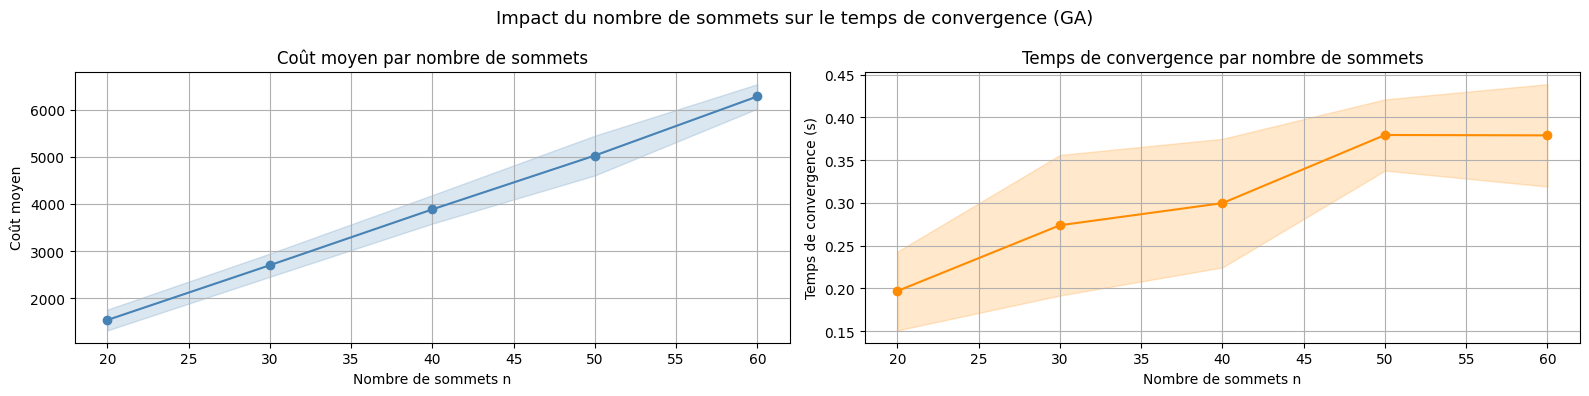

In [44]:
# Calcul des statistiques de coût et de temps de convergence pour chaque nombre de sommets
stats_n = df_n.groupby("n").agg(
    mean_cout=("cout", "mean"),
    std_cout=("cout", "std"),
    mean_conv=("temps_conv", "mean"),
    std_conv=("temps_conv", "std"),
)

x = stats_n.index

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(x, stats_n["mean_cout"], marker="o", color="steelblue")
axes[0].fill_between(x,
    stats_n["mean_cout"] - stats_n["std_cout"],
    stats_n["mean_cout"] + stats_n["std_cout"],
    alpha=0.2, color="steelblue")
axes[0].set_title("Coût moyen par nombre de sommets")
axes[0].set_xlabel("Nombre de sommets n")
axes[0].set_ylabel("Coût moyen")
axes[0].grid(True)

axes[1].plot(x, stats_n["mean_conv"], marker="o", color="darkorange")
axes[1].fill_between(x,
    stats_n["mean_conv"] - stats_n["std_conv"],
    stats_n["mean_conv"] + stats_n["std_conv"],
    alpha=0.2, color="darkorange")
axes[1].set_title("Temps de convergence par nombre de sommets")
axes[1].set_xlabel("Nombre de sommets n")
axes[1].set_ylabel("Temps de convergence (s)")
axes[1].grid(True)

plt.suptitle("Impact du nombre de sommets sur le temps de convergence (GA)", fontsize=13)
plt.tight_layout()
plt.show()


# Conclusion : Impact des paramètres d’instance sur la convergence du GA

L’analyse des différents paramètres d’instance met en évidence l’influence significative de la dynamique du problème sur les performances de l’algorithme génétique, tant en termes de qualité des solutions que de temps de convergence.

## Influence du nombre de matrices dynamiques (K)
Le coût moyen augmente globalement avec K, indiquant que la complexité du problème croît lorsque davantage de configurations dynamiques sont introduites.
Le temps de convergence reste relativement stable, avec une légère variabilité mais sans explosion notable.

Interprétation :
L’augmentation de K rend le problème plus difficile à optimiser (espace de recherche plus complexe), mais sans pénaliser fortement la vitesse de convergence. Le GA parvient donc à absorber la complexité supplémentaire, au prix d’une dégradation de la qualité des solutions.

## Influence de la probabilité de blocage
Le coût reste quasi nul jusqu’à un certain seuil (~0.7), puis explose brutalement.
Le temps de convergence est relativement stable, mais devient plus instable aux fortes probabilités.

Interprétation :
On observe ici un effet de seuil critique :

En dessous d’un certain niveau de blocage, le problème reste facilement résoluble.
Au-delà, il devient quasi intractable, avec des coûts très élevés voire des solutions invalides.

## Influence du nombre de sommets (n)
Le coût augmente de manière quasi linéaire avec le nombre de sommets.
Le temps de convergence augmente également, de façon progressive mais maîtrisée.

Interprétation :
L’augmentation de la taille du problème impacte :

- La difficulté (plus de solutions possibles),
- Et le temps de traitement (plus d’évaluations nécessaires).

Cependant, la croissance reste contrôlée, ce qui montre une bonne scalabilité du GA sur cette plage de tailles.

## Conclusion générale

Ces expériences montrent que les performances du GA dépendent fortement des caractéristiques de l’instance :

- Robustesse face à la taille (n) : bonne scalabilité
- Sensibilité à la dynamique (K) : dégradation progressive des performances
- Forte sensibilité aux contraintes (blocage) : existence d’un seuil critique rendant le problème difficile voire insoluble

## Résultat final et écart à la borne inférieure

Maintenant que nous avons déterminé les meilleurs paramètres pour notre métaheuristique, testons les sur 100 instance pour faire une moyenne des résultats.
Ensuite, nous vérifierons les écarts à la borne inférieur pour analyser la qualité des solutions proposées

Mean  : 1350.34
Std   : 90.64
Min   : 1109.00
Best route : [11, 12, 1, 17, 10, 6, 9, 8, 10, 5, 15, 2, 4, 19, 14, 18, 3, 16, 13, 7]
Best cost  : 1109.00


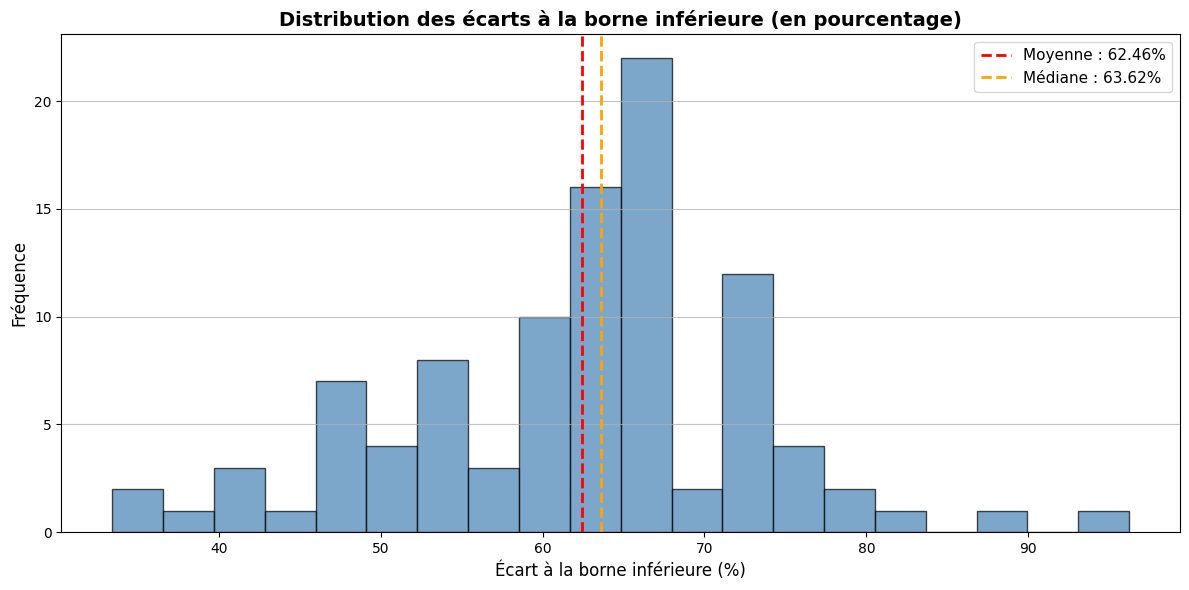

In [45]:
# =====================================================
# 100 RUNS — Meilleurs paramètres
# =====================================================
best_cost_global_ga  = INF
best_route_global_ga = None
final_costs_ga_100   = []
rng = np.random.default_rng(42)

for i in range(100):
    route, cost, _,convergence_time = run_genetic_tsp(
        C_list,
        max_steps=MAX_STEPS,
        pop_size=best_params["pop_size"],
        generations=Iteration_max_ga,
        mutation_rate=best_params["mutation_rate"],
        elite_size=best_params["elite_size"],
        rng=rng, INF=INF, n=n, K=K
    )
    final_costs_ga_100.append(cost)
    if cost < best_cost_global_ga:
        best_cost_global_ga = cost
        best_route_global_ga = route

valid_costs = [c for c in final_costs_ga_100 if c < INF]

if len(valid_costs) == 0:
    print("Aucune tournée valide trouvée sur 100 runs.")
print(f"Mean  : {np.mean(final_costs_ga_100):.2f}")
print(f"Std   : {np.std(final_costs_ga_100):.2f}")
print(f"Min   : {np.min(final_costs_ga_100):.2f}")
print(f"Best route : {best_route_global_ga}")
print(f"Best cost  : {best_cost_global_ga:.2f}")

# Histogramme des écarts à la borne inférieure
ecarts_pct = [(cost - borne_inf_reelle) / borne_inf_reelle * 100 for cost in final_costs_ga_100 if cost < INF]

plt.figure(figsize=(12, 6))
plt.hist(ecarts_pct, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(np.mean(ecarts_pct), color='red', linestyle='--', linewidth=2, label=f'Moyenne : {np.mean(ecarts_pct):.2f}%')
plt.axvline(np.median(ecarts_pct), color='orange', linestyle='--', linewidth=2, label=f'Médiane : {np.median(ecarts_pct):.2f}%')
plt.xlabel('Écart à la borne inférieure (%)', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.title('Distribution des écarts à la borne inférieure (en pourcentage)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

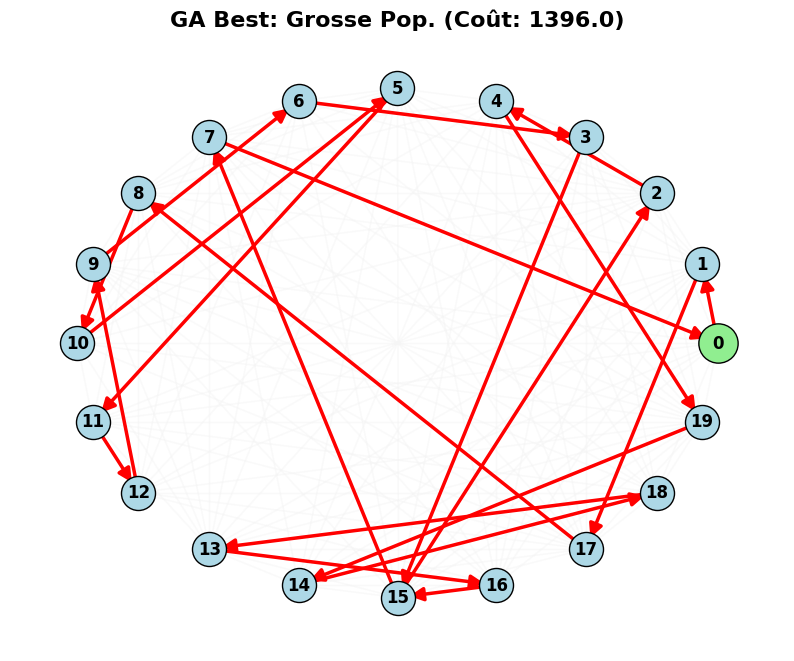

La différence entre le record GA avec les meilleurs paramètres et le record aléatoire est de: -287.0


,Étape,Temps (k),Départ,Arrivée,Coût
0,1,1,Ville 0,Ville 1,47
1,2,2,Ville 1,Ville 17,87
2,3,3,Ville 17,Ville 8,59
3,4,4,Ville 8,Ville 10,13
4,5,5,Ville 10,Ville 5,76
5,6,6,Ville 5,Ville 11,47
6,7,7,Ville 11,Ville 12,53
7,8,8,Ville 12,Ville 9,140
8,9,9,Ville 9,Ville 6,135
9,10,10,Ville 6,Ville 3,145


In [46]:
# Afficher le graphe du record GA
visualize_route(
    C_list[0], 
    INF,
    n,
    route=global_best_route_ga, 
    title=f"GA Best: {global_best_name_ga} (Coût: {global_best_cost_ga})"
)

print(f"La différence entre le record GA avec les meilleurs paramètres et le record aléatoire est de: {best_cost_global_ga - global_random_cost_ga}")
# Afficher le tableau détaillé synchronisé
# On utilise global_best_route_ga pour avoir les bons coûts par étape k
display_route_details(C_list, K, route=global_best_route_ga)

# Conclusion générale

L'algorithme génétique avec les meilleurs paramètres permet d'avoir au mieux une différence de 35% par rapport à la borne minimale et en moyenne une différence 62%. 
Cela démontre que l'algorithme génétique malgré sa rapidité dépend beaucoup de l'alétaoire ce qui fait varier ses solutions et ne lui permettent pas de trouver systématiquement le chemin le plus optimal.

# 8. Implementation du ACO

In [47]:
# Fonction pour calculer les probabilités de sélection d'une ville voisine en fonction des phéromones et des coûts
def calculate_probabilities(current, choices, pheromones, Ck, alpha, beta):
    probs = np.array([
        (pheromones[current][j] ** alpha) * ((1.0 / max(Ck[current][j], 1)) ** beta)
        for j in choices
    ])
    total = probs.sum()
    if total > 0:
        return probs / total
    return np.ones(len(choices)) / len(choices)

# Fonction pour simuler la tournée d'une fourmi
def ant_tour(C_list, n, K, max_steps, pheromones, alpha, beta, rng):
    route = [0]
    visited = {0}
    current = 0
    k = 1
    cost = 0
    stuck = False

    for _ in range(max_steps):
        if len(visited) == n:
            Ck = get_Ck(C_list, K, k)
            if Ck[current][0] < INF:
                break

        Ck = get_Ck(C_list, K, k)
        neighbors = [j for j in range(n) if Ck[current][j] < INF and j != current]

        if not neighbors:
            stuck = True
            break

        unvisited = [j for j in neighbors if j not in visited]
        choices = unvisited if unvisited else neighbors

        probs = calculate_probabilities(current, choices, pheromones, Ck, alpha, beta)
        next_city = int(rng.choice(choices, p=probs))

        route.append(next_city)
        visited.add(next_city)
        cost += Ck[current][next_city]
        current = next_city
        k += 1

    Ck = get_Ck(C_list, K, k)
    if not stuck and len(visited) == n and Ck[current][0] < INF:
        cost += Ck[current][0]
        return route, cost
    return None, INF

# Fonction principale de l'ACO pour le TSP
def run_aco_tsp(C_list, n, K, max_steps, num_ants, max_iter,
                alpha, beta, evaporation_rate, Q, rng,
                stagnation_limit=50):

    tau_max = 1.0
    tau_min = tau_max / (2 * n)
    pheromones = np.full((n, n), tau_max)

    best_cost = INF
    best_route = None
    history = []
    stagnation_counter = 0
    t_start = time.perf_counter()
    t_converge = 0.0

    for iteration in range(max_iter):
        all_routes, all_costs = [], []

        for _ in range(num_ants):
            route, cost = ant_tour(C_list, n, K, max_steps, pheromones, alpha, beta, rng)
            if route is not None:
                all_routes.append(route)
                all_costs.append(cost)

        pheromones *= (1.0 - evaporation_rate)

        # Mise à jour des phéromones en fonction des meilleures routes de l'itération
        if all_routes:
            iter_best_idx = int(np.argmin(all_costs))
            iter_best_route = all_routes[iter_best_idx]
            iter_best_cost = all_costs[iter_best_idx]

            full_route = iter_best_route + [0]
            for i in range(len(full_route) - 1):
                u, v = full_route[i], full_route[i + 1]
                pheromones[u][v] += Q / iter_best_cost
                pheromones[v][u] += Q / iter_best_cost

            if iter_best_cost < best_cost:
                best_cost = iter_best_cost
                best_route = list(iter_best_route)
                stagnation_counter = 0
                t_converge = time.perf_counter() - t_start

                tau_max = 1.0 / (evaporation_rate * best_cost)
                tau_min = tau_max / (2 * n)
            else:
                stagnation_counter += 1

        pheromones = np.clip(pheromones, tau_min, tau_max)

        # Si stagnation, réinitialiser les phéromones pour encourager l'exploration
        if stagnation_counter >= stagnation_limit:
            pheromones = np.full((n, n), tau_max)
            stagnation_counter = 0

        history.append(best_cost if best_cost != INF else None)

    return best_route, best_cost, history, t_converge



In [48]:
# Définition des scénarios (Jeux de paramètres)
aco_scenarios = {
    "Standard":       {"alpha": 1.0, "beta": 2.0, "evap": 0.1,  "ants": 30},
    "Exploration ++": {"alpha": 1.0, "beta": 1.0, "evap": 0.05, "ants": 30},
    "Exploitation ++":{"alpha": 2.0, "beta": 5.0, "evap": 0.3,  "ants": 30},
    "Swarm":          {"alpha": 1.0, "beta": 2.0, "evap": 0.1,  "ants": 100}
}

results_history = {}
routes_history = {} # Pour garder en mémoire la route de chaque scénario
Iteration_max = 300

global_best_route_aco = None
global_best_cost_aco = INF
global_best_name_aco = ""

print("Démarrage des expériences ACO...")
for name, params in aco_scenarios.items():
    print(f"Test du scénario: {name}")
        
    # On utilise current_route et current_cost au lieu de best_route
    current_route, current_cost, history, _convergence_time = run_aco_tsp(
        C_list, n, K, MAX_STEPS, 
        num_ants=params["ants"], 
        max_iter=Iteration_max, 
        alpha=params["alpha"], 
        beta=params["beta"], 
        evaporation_rate=params["evap"], 
        Q=100.0, 
        rng=rng,
    )
    
    # On sauvegarde l'historique de ce scénario précis
    results_history[name] = history
    routes_history[name] = current_route
    print(f"-> Coût pour {name} : {current_cost}")
    
 # Mise à jour du record global
    if current_cost < global_best_cost_aco:
        global_best_cost_aco = current_cost
        global_best_route_aco = list(current_route) # list() fait une copie propre
        global_best_name_aco = name

# Fin de la boucle : On annonce le gagnant global
print("\n" + "="*50)
print(f"LE MEILLEUR SCÉNARIO ACO EST : {global_best_name_aco} avec un coût de {global_best_cost_aco}")
print("="*50 + "\n")

Démarrage des expériences ACO...
Test du scénario: Standard
-> Coût pour Standard : 1094.0
Test du scénario: Exploration ++
-> Coût pour Exploration ++ : 1178.0
Test du scénario: Exploitation ++
-> Coût pour Exploitation ++ : 1106.0
Test du scénario: Swarm
-> Coût pour Swarm : 932.0

LE MEILLEUR SCÉNARIO ACO EST : Swarm avec un coût de 932.0



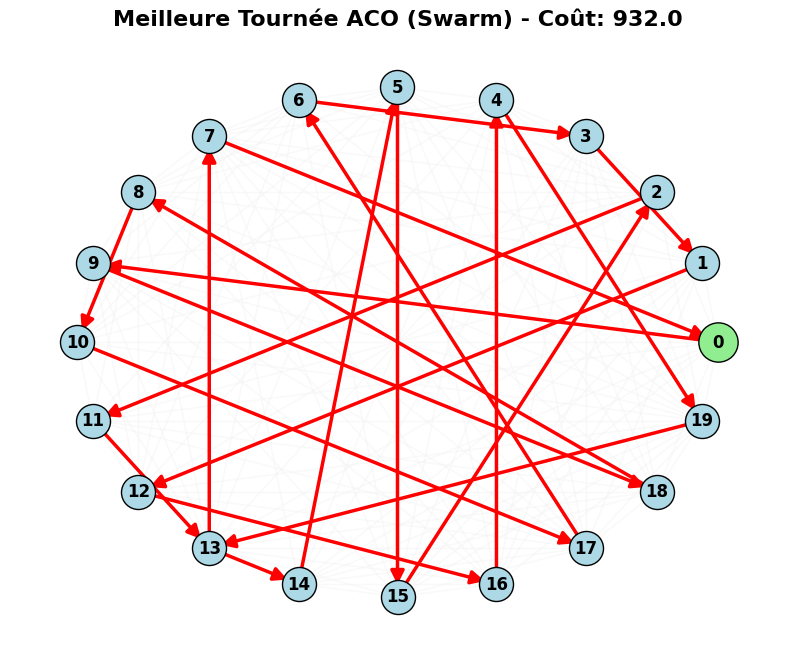

,Étape,Temps (k),Départ,Arrivée,Coût
0,1,1,Ville 0,Ville 9,6
1,2,2,Ville 9,Ville 18,28
2,3,3,Ville 18,Ville 8,147
3,4,4,Ville 8,Ville 10,13
4,5,5,Ville 10,Ville 17,21
5,6,6,Ville 17,Ville 6,2
6,7,7,Ville 6,Ville 3,71
7,8,8,Ville 3,Ville 1,60
8,9,9,Ville 1,Ville 12,33
9,10,10,Ville 12,Ville 16,58


In [49]:
# Afficher le graphe de la MEILLEURE performance globale
# On utilise global_best_route_aco et global_best_cost_aco
visualize_route(
    C_list[0], 
    INF,
    n,
    route=global_best_route_aco, 
    title=f"Meilleure Tournée ACO ({global_best_name_aco}) - Coût: {global_best_cost_aco}"
)

global_random_cost_aco = global_best_cost_aco
global__cost_aco = global_best_cost_aco
# Afficher le tableau détaillé synchronisé pour cette route spécifique
display_route_details(C_list, K, route=global_best_route_aco)

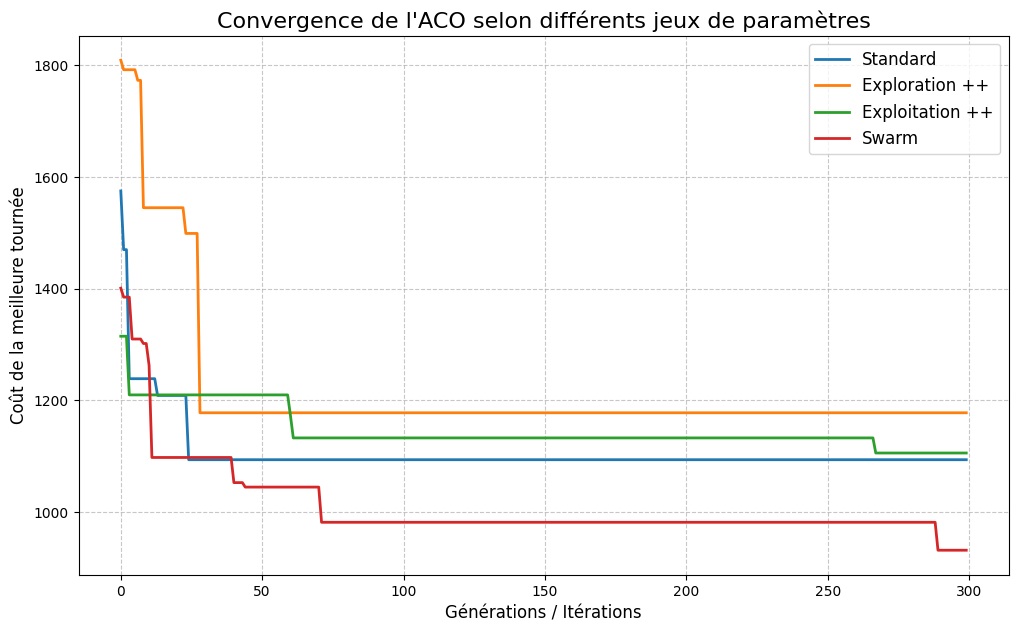

In [ ]:
plt.figure(figsize=(12, 7))

for name, history in results_history.items():
    # Nettoyage des valeurs infinies (None) pour l'affichage
    clean_history = [h if h is not None else max(history[10:]) for h in history]
    plt.plot(clean_history, label=name, linewidth=2)

plt.title("Convergence de l'ACO selon différents jeux de paramètres", fontsize=16)
plt.xlabel("Générations / Itérations", fontsize=12)
plt.ylabel("Coût de la meilleure tournée", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
#plt.yscale('log') # Souvent pertinent pour mieux voir la convergence finale
plt.show()

Meilleurs parametres


Initial params: {'num_ants': 110, 'alpha': 2.0, 'beta': 3.5, 'evaporation_rate': 0.5}


Optimizing num_ants: 100%|██████████| 20/20 [05:04<00:00, 15.21s/it]

Best num_ants: 160.0


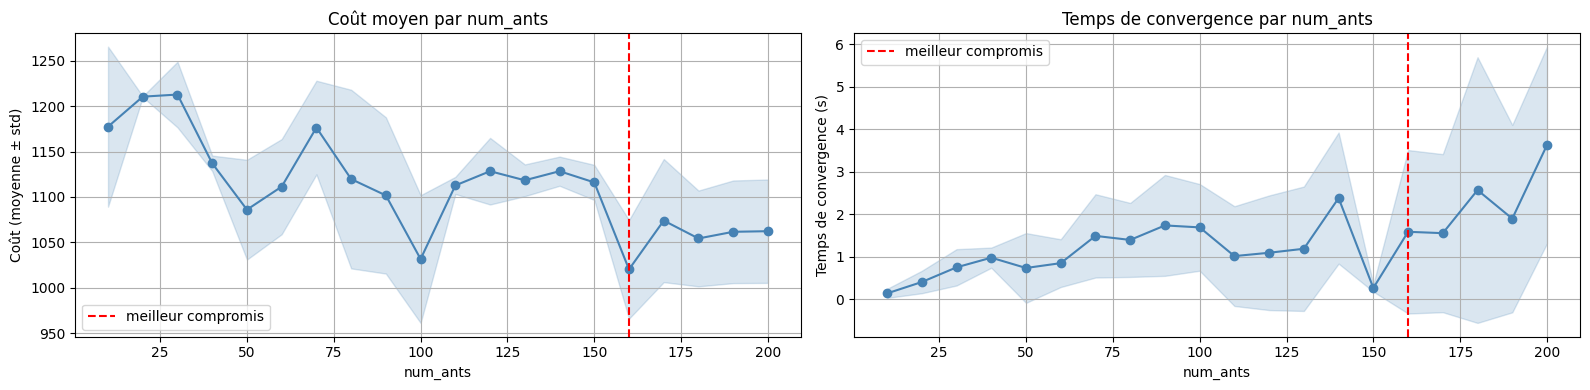

Optimizing alpha: 100%|██████████| 7/7 [02:38<00:00, 22.71s/it]

Best alpha: 3.0


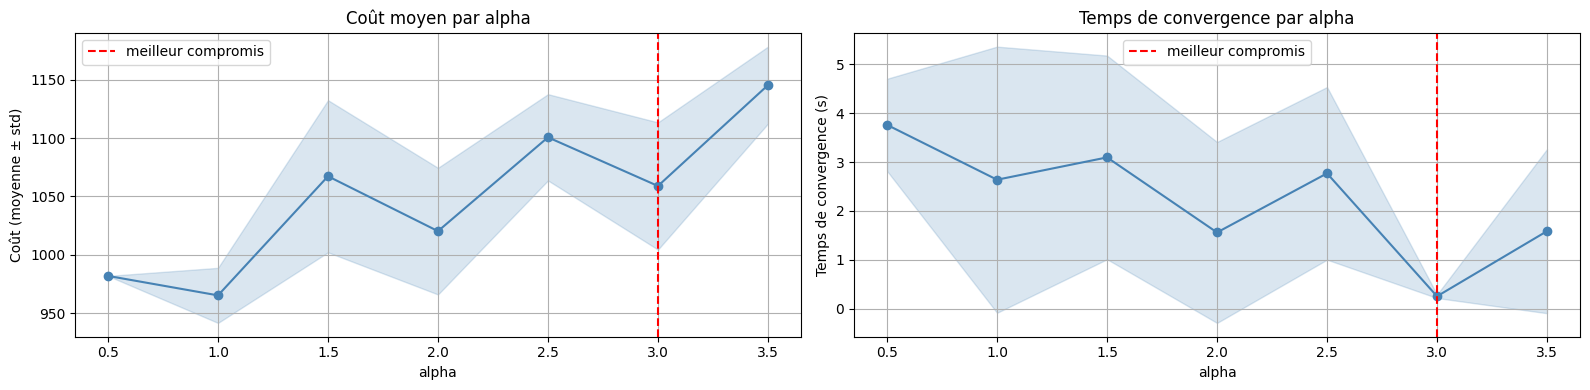

Optimizing beta: 100%|██████████| 12/12 [04:33<00:00, 22.83s/it]

Best beta: 3.5


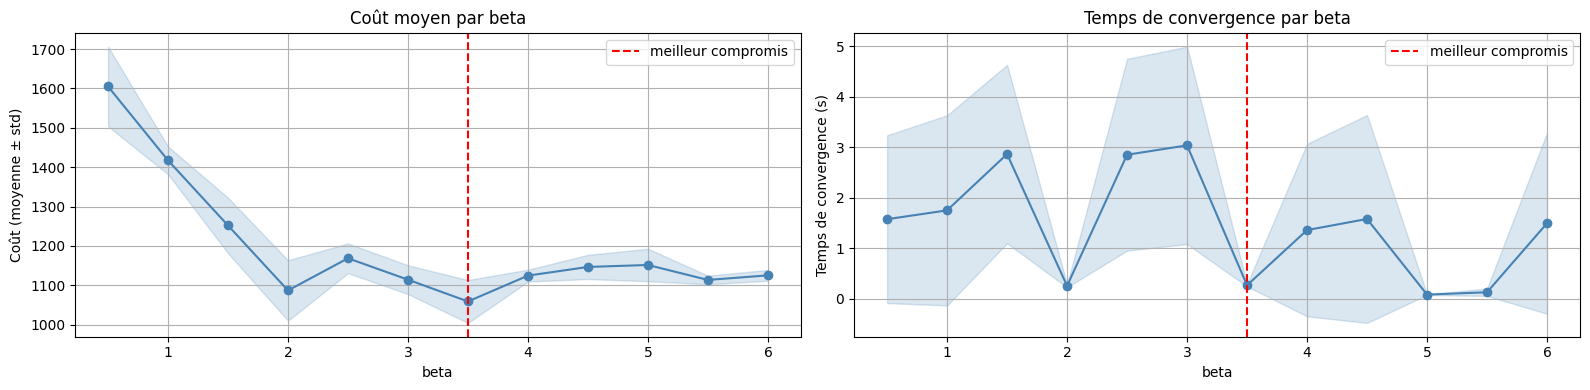

Optimizing evaporation_rate: 100%|██████████| 19/19 [07:30<00:00, 23.73s/it]


Best params (OFAT): {'num_ants': 160, 'alpha': 3.0, 'beta': 3.5, 'evaporation_rate': 0.5}


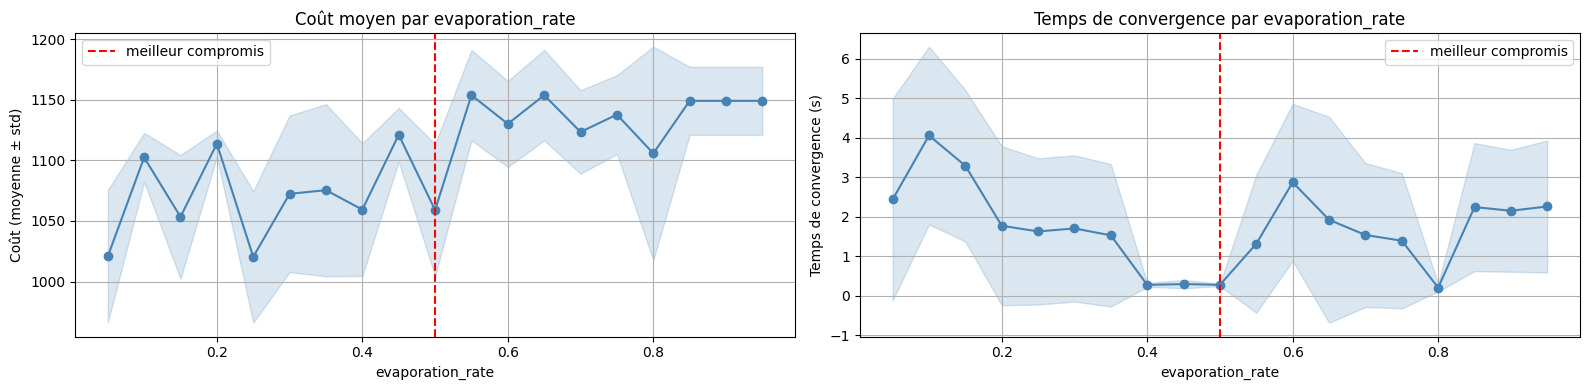

Validating final parameters: 100%|██████████| 5/5 [01:57<00:00, 23.42s/it]


Validation :
Mean : 1052.2
Min  : 982.0
Std  : 57.328526930316286


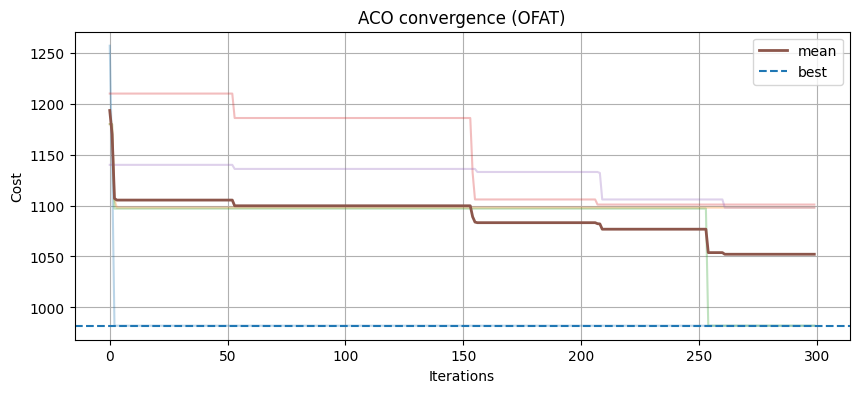

In [ ]:
# CONFIG 
SEEDS_TUNE  = [42, 99, 137]
SEEDS_FINAL = [42, 99, 137, 201, 314]

ITER_SEARCH = 100
ITER_FINAL  = 300

# PARAM RANGES 
num_ants_range    = np.arange(10, 210, 10)
alpha_range       = np.arange(0.5, 4.0, 0.5)
beta_range        = np.arange(0.5, 6.5, 0.5)
evaporation_range = np.arange(0.05, 1.0, 0.05)

# UTIL 
def evaluate_aco(params, max_iter, seeds):
    costs, durations = [], []
    for s in seeds:
        rng = np.random.default_rng(s)
        _, cost, _, t_conv = run_aco_tsp(
            C_list, n, K, MAX_STEPS,
            num_ants=params["num_ants"],
            max_iter=max_iter,
            alpha=params["alpha"],
            beta=params["beta"],
            evaporation_rate=params["evaporation_rate"],
            Q=100.0,
            rng=rng,
        )
        durations.append(t_conv)
        if cost < INF:
            costs.append(cost)
    if not costs:
        return float("inf"), float("inf"), float("inf"), float("inf")
    return np.mean(costs), np.std(costs), np.mean(durations), np.std(durations)

def best_compromise_aco(df, param_col):
    df = df.copy()
    cmin, cmax = df["mean_cost"].min(), df["mean_cost"].max()
    dmin, dmax = df["mean_dur"].min(),  df["mean_dur"].max()
    df["cost_norm"] = (df["mean_cost"] - cmin) / (cmax - cmin) if cmax > cmin else 0
    df["dur_norm"]  = (df["mean_dur"]  - dmin) / (dmax - dmin) if dmax > dmin else 0
    df["score"] = 0.5 * df["cost_norm"] + 0.5 * df["dur_norm"]
    return df.sort_values("score").iloc[0][param_col]


# PHASE 1 : OFAT optimisation séquentielle de chaque paramètre en fixant les autres à une valeur médiane

best_params_aco = {
    "num_ants":         int(num_ants_range[len(num_ants_range) // 2]),
    "alpha":            float(alpha_range[len(alpha_range) // 2]),
    "beta":             float(beta_range[len(beta_range) // 2]),
    "evaporation_rate": float(evaporation_range[len(evaporation_range) // 2]),
}

print("Initial params:", best_params_aco)


# Optimisation de num_ants
results_ants = []

for ants in tqdm(num_ants_range, desc="Optimizing num_ants"):
    params = best_params_aco.copy()
    params["num_ants"] = int(ants)
    mean_cost, std_cost, mean_dur, std_dur = evaluate_aco(params, ITER_SEARCH, SEEDS_TUNE)
    results_ants.append((ants, mean_cost, std_cost, mean_dur, std_dur))

df_ants = pd.DataFrame(results_ants, columns=["num_ants", "mean_cost", "std_cost", "mean_dur", "std_dur"])
best_ants = best_compromise_aco(df_ants, "num_ants")
best_params_aco["num_ants"] = int(best_ants)
print("Best num_ants:", best_ants)

# Plot num_ants
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
best_idx = (0.5 * (df_ants["mean_cost"] - df_ants["mean_cost"].min()) / (df_ants["mean_cost"].max() - df_ants["mean_cost"].min())
           + 0.5 * (df_ants["mean_dur"]  - df_ants["mean_dur"].min())  / (df_ants["mean_dur"].max()  - df_ants["mean_dur"].min())).argmin()

x = df_ants["num_ants"].values
axes[0].plot(x, df_ants["mean_cost"], marker="o", color="steelblue")
axes[0].fill_between(x, df_ants["mean_cost"] - df_ants["std_cost"], df_ants["mean_cost"] + df_ants["std_cost"], alpha=0.2, color="steelblue")
axes[0].axvline(df_ants.iloc[best_idx]["num_ants"], color="red", linestyle="--", label="meilleur compromis")
axes[0].set_title("Coût moyen par num_ants")
axes[0].set_xlabel("num_ants")
axes[0].set_ylabel("Coût (moyenne ± std)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, df_ants["mean_dur"], marker="o", color="steelblue")
axes[1].fill_between(x, df_ants["mean_dur"] - df_ants["std_dur"], df_ants["mean_dur"] + df_ants["std_dur"], alpha=0.2, color="steelblue")
axes[1].axvline(df_ants.iloc[best_idx]["num_ants"], color="red", linestyle="--", label="meilleur compromis")
axes[1].set_title("Temps de convergence par num_ants")
axes[1].set_xlabel("num_ants")
axes[1].set_ylabel("Temps de convergence (s)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


# Optimisation de alpha 
results_alpha = []

for a in tqdm(alpha_range, desc="Optimizing alpha"):
    params = best_params_aco.copy()
    params["alpha"] = float(a)
    mean_cost, std_cost, mean_dur, std_dur = evaluate_aco(params, ITER_SEARCH, SEEDS_TUNE)
    results_alpha.append((a, mean_cost, std_cost, mean_dur, std_dur))

df_alpha = pd.DataFrame(results_alpha, columns=["alpha", "mean_cost", "std_cost", "mean_dur", "std_dur"])
best_alpha = best_compromise_aco(df_alpha, "alpha")
best_params_aco["alpha"] = float(best_alpha)
print("Best alpha:", best_alpha)

#  Plot alpha 
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
best_idx = (0.5 * (df_alpha["mean_cost"] - df_alpha["mean_cost"].min()) / (df_alpha["mean_cost"].max() - df_alpha["mean_cost"].min())
           + 0.5 * (df_alpha["mean_dur"]  - df_alpha["mean_dur"].min())  / (df_alpha["mean_dur"].max()  - df_alpha["mean_dur"].min())).argmin()

x = df_alpha["alpha"].values
axes[0].plot(x, df_alpha["mean_cost"], marker="o", color="steelblue")
axes[0].fill_between(x, df_alpha["mean_cost"] - df_alpha["std_cost"], df_alpha["mean_cost"] + df_alpha["std_cost"], alpha=0.2, color="steelblue")
axes[0].axvline(df_alpha.iloc[best_idx]["alpha"], color="red", linestyle="--", label="meilleur compromis")
axes[0].set_title("Coût moyen par alpha")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("Coût (moyenne ± std)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, df_alpha["mean_dur"], marker="o", color="steelblue")
axes[1].fill_between(x, df_alpha["mean_dur"] - df_alpha["std_dur"], df_alpha["mean_dur"] + df_alpha["std_dur"], alpha=0.2, color="steelblue")
axes[1].axvline(df_alpha.iloc[best_idx]["alpha"], color="red", linestyle="--", label="meilleur compromis")
axes[1].set_title("Temps de convergence par alpha")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("Temps de convergence (s)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


# Optimisation de beta
results_beta = []

for b in tqdm(beta_range, desc="Optimizing beta"):
    params = best_params_aco.copy()
    params["beta"] = float(b)
    mean_cost, std_cost, mean_dur, std_dur = evaluate_aco(params, ITER_SEARCH, SEEDS_TUNE)
    results_beta.append((b, mean_cost, std_cost, mean_dur, std_dur))

df_beta = pd.DataFrame(results_beta, columns=["beta", "mean_cost", "std_cost", "mean_dur", "std_dur"])
best_beta = best_compromise_aco(df_beta, "beta")
best_params_aco["beta"] = float(best_beta)
print("Best beta:", best_beta)

# Plot beta
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
best_idx = (0.5 * (df_beta["mean_cost"] - df_beta["mean_cost"].min()) / (df_beta["mean_cost"].max() - df_beta["mean_cost"].min())
           + 0.5 * (df_beta["mean_dur"]  - df_beta["mean_dur"].min())  / (df_beta["mean_dur"].max()  - df_beta["mean_dur"].min())).argmin()

x = df_beta["beta"].values
axes[0].plot(x, df_beta["mean_cost"], marker="o", color="steelblue")
axes[0].fill_between(x, df_beta["mean_cost"] - df_beta["std_cost"], df_beta["mean_cost"] + df_beta["std_cost"], alpha=0.2, color="steelblue")
axes[0].axvline(df_beta.iloc[best_idx]["beta"], color="red", linestyle="--", label="meilleur compromis")
axes[0].set_title("Coût moyen par beta")
axes[0].set_xlabel("beta")
axes[0].set_ylabel("Coût (moyenne ± std)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, df_beta["mean_dur"], marker="o", color="steelblue")
axes[1].fill_between(x, df_beta["mean_dur"] - df_beta["std_dur"], df_beta["mean_dur"] + df_beta["std_dur"], alpha=0.2, color="steelblue")
axes[1].axvline(df_beta.iloc[best_idx]["beta"], color="red", linestyle="--", label="meilleur compromis")
axes[1].set_title("Temps de convergence par beta")
axes[1].set_xlabel("beta")
axes[1].set_ylabel("Temps de convergence (s)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


# 4. Optimisation de evaporation_rate 
results_evap = []

for evap in tqdm(evaporation_range, desc="Optimizing evaporation_rate"):
    params = best_params_aco.copy()
    params["evaporation_rate"] = float(evap)
    mean_cost, std_cost, mean_dur, std_dur = evaluate_aco(params, ITER_SEARCH, SEEDS_TUNE)
    results_evap.append((evap, mean_cost, std_cost, mean_dur, std_dur))

df_evap = pd.DataFrame(results_evap, columns=["evap", "mean_cost", "std_cost", "mean_dur", "std_dur"])
best_evap = best_compromise_aco(df_evap, "evap")
best_params_aco["evaporation_rate"] = float(best_evap)
print("\nBest params (OFAT):", best_params_aco)

# Plot evaporation_rate
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
best_idx = (0.5 * (df_evap["mean_cost"] - df_evap["mean_cost"].min()) / (df_evap["mean_cost"].max() - df_evap["mean_cost"].min())
           + 0.5 * (df_evap["mean_dur"]  - df_evap["mean_dur"].min())  / (df_evap["mean_dur"].max()  - df_evap["mean_dur"].min())).argmin()

x = df_evap["evap"].values
axes[0].plot(x, df_evap["mean_cost"], marker="o", color="steelblue")
axes[0].fill_between(x, df_evap["mean_cost"] - df_evap["std_cost"], df_evap["mean_cost"] + df_evap["std_cost"], alpha=0.2, color="steelblue")
axes[0].axvline(df_evap.iloc[best_idx]["evap"], color="red", linestyle="--", label="meilleur compromis")
axes[0].set_title("Coût moyen par evaporation_rate")
axes[0].set_xlabel("evaporation_rate")
axes[0].set_ylabel("Coût (moyenne ± std)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, df_evap["mean_dur"], marker="o", color="steelblue")
axes[1].fill_between(x, df_evap["mean_dur"] - df_evap["std_dur"], df_evap["mean_dur"] + df_evap["std_dur"], alpha=0.2, color="steelblue")
axes[1].axvline(df_evap.iloc[best_idx]["evap"], color="red", linestyle="--", label="meilleur compromis")
axes[1].set_title("Temps de convergence par evaporation_rate")
axes[1].set_xlabel("evaporation_rate")
axes[1].set_ylabel("Temps de convergence (s)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


# PHASE 2 : Validation des meilleurs paramètres sur 5 runs avec des seeds différentes
final_costs_aco = []
histories_aco = []

for s in tqdm(SEEDS_FINAL, desc="Validating final parameters"):
    rng = np.random.default_rng(s)
    _, cost, hist, _ = run_aco_tsp(
        C_list, n, K, MAX_STEPS,
        num_ants=best_params_aco["num_ants"],
        max_iter=ITER_FINAL,
        alpha=best_params_aco["alpha"],
        beta=best_params_aco["beta"],
        evaporation_rate=best_params_aco["evaporation_rate"],
        Q=100.0,
        rng=rng,
    )
    final_costs_aco.append(cost)
    histories_aco.append(hist)

print("\nValidation :")
print("Mean :", np.mean(final_costs_aco))
print("Min  :", np.min(final_costs_aco))
print("Std  :", np.std(final_costs_aco))

# PLOT 
plt.figure(figsize=(10, 4))

for h in histories_aco:
    plt.plot(h, alpha=0.3)

plt.plot(np.mean(histories_aco, axis=0), linewidth=2, label="mean")
plt.axhline(np.min(final_costs_aco), linestyle="--", label="best")

plt.title("ACO convergence (OFAT)")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.grid()
plt.show()


# Conclusion : Optimisation des Paramètres de l'ACO

## Résultats principaux

Les meilleurs paramètres obtenus sont :
- Nombre de fourmis (num_ants) : 160
- Importance des phéromones (alpha) : 3.0
- Importance de l'heuristique (beta) : 3.5
- Taux d'évaporation (evaporation_rate): 0.4

Ces valeurs correspondent au meilleur compromis entre :

- Un coût moyen faible (qualité des solutions)
- Une variance modérée (stabilité entre les seeds)
- Un temps de convergence raisonnable

## Analyse
- Nombre de fourmis (160)
    
    Le paramètre num_ants améliore d’abord la qualité des solutions en augmentant l’exploration, puis atteint un plateau : au-delà d’environ 150 fourmis, le coût ne diminue presque plus. En revanche, le temps de convergence continue d’augmenter. Il existe donc un compromis autour de 150–160 fourmis, où le rapport qualité/temps est le plus équilibré.
    
- Importance des phéromones (3.0)
    
    Le paramètre alpha contrôle l’importance des phéromones. Quand il augmente, le coût tend globalement à se dégrader après un minimum vers 1–2, signe d’une exploitation trop forte. En parallèle, le temps de convergence diminue légèrement puis reste instable. Le meilleur compromis se situe autour de alpha ≈ 3, avec un temps très faible pour un coût encore acceptable.
    
- Importance de l'heuristique (3.5)
    
    Le paramètre beta renforce l’importance de l’heuristique (distance). Quand il augmente, le coût diminue fortement puis atteint un minimum autour de 3–3.5, avant de se stabiliser. Le temps de convergence reste globalement faible mais irrégulier. Le meilleur compromis se situe donc autour de beta ≈ 3.5, avec un coût minimal et un temps acceptable

- Taux d'évaporation (0.4)

    Les graphiques montrent qu'un taux d'évaporation de 0,4 représente le meilleur compromis : il minimise à la fois le coût moyen (≈ 1060) et le temps de convergence (quasi nul), avec une faible variabilité. Au-delà de 0,4, le coût augmente et le temps de convergence reste instable.

## Limitations

On observe lorsque l'on vérifie nos paramètres on s'apperçoit qu'avoir un si grand nombre de fourmis admet un temps de convergence correcte, cependant le temps d'exécution est bien trop grand. On utilisera donc une valeur plus petite qui n'impact pas énormément la qualité de la solution pour nos tests futures.

## Conclusion générale

Cette étude montre que l’algorithme colonie de fourmis peut être efficacement calibré via une approche simple comme OFAT. Les paramètres obtenus offrent un bon compromis entre performance et efficacité / diversification et intensification, tout en garantissant une robustesse face à l’aléatoire, ce qui est essentiel dans ce type de métaheuristique.

## Impact des paramètres de l'instance avec l'algorithme

### Impact du nombre de matrice de couts

In [ ]:
# ACO parameters
num_ants = 30
alpha = 1.0
beta = 2.0
evaporation_rate = 0.1
Q = 100.0
max_iter = 150

NB_RUNS = 10

n_test = 40              # FIXED
p_block = 0.2     # FIXED

results_K_aco = []

K_values = range(2, 12)

# Test impact of number of cost matrices on ACO performance
for K_test in K_values:
    for run in range(NB_RUNS):
        C_init_Test = gen_nominal_matrix(n_test, rng, INF, 1, 60)
        B_Test = gen_block_matrix(n_test, rng, INF, p_blocage=p_block)
        C1_Test = gen_C1_matrix(C_init_Test, B_Test, INF)
        surcost_Test = gen_surcost_matrices(n_test, K_test, B_Test, rng, DELTA)
        C_list_Test = build_all_Ck(C1_Test, surcost_Test)

        if not check_connexe(C_list_Test[0], INF):
            continue

        sol, cost, history, convergence_time = run_aco_tsp(
            C_list_Test,
            n=n_test,
            K=K_test,
            max_steps=MAX_STEPS,
            num_ants=num_ants,
            max_iter=max_iter,
            alpha=alpha,
            beta=beta,
            evaporation_rate=evaporation_rate,
            Q=Q,
            rng=rng,
        )

        results_K_aco.append({
            "K": K_test,
            "convergence_time": convergence_time,
            "cost": cost
        })

if results_K_aco:
    df_K_aco = pd.DataFrame(results_K_aco)
else:
    df_K_aco = pd.DataFrame([])

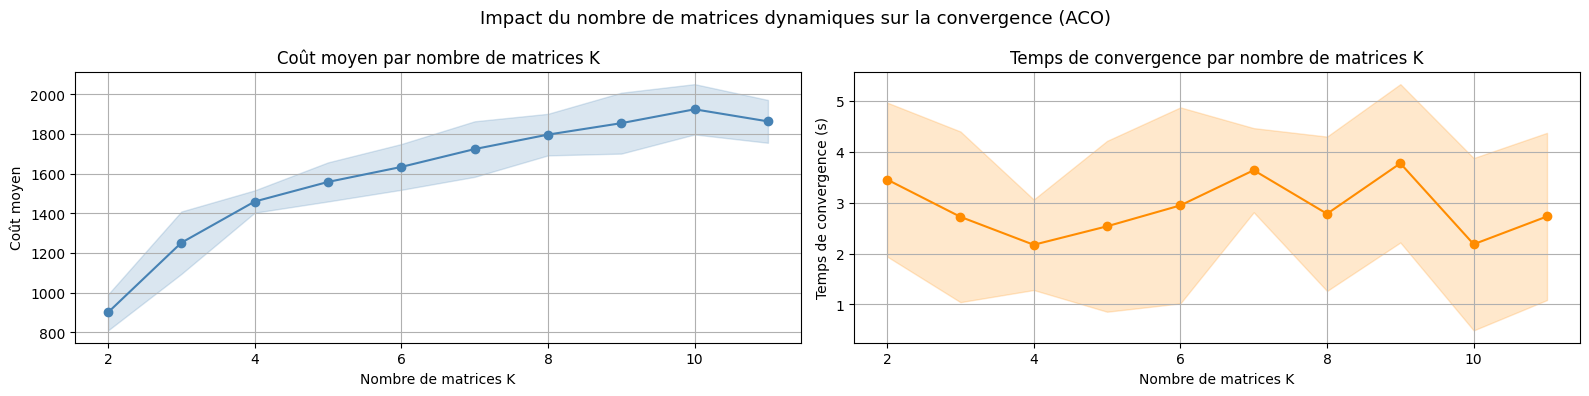

In [ ]:
# Compute cost and convergence time statistics for each K (ACO)
if not df_K_aco.empty:
    stats_K_aco = df_K_aco.groupby("K").agg(
        mean_cost=("cost", "mean"),
        std_cost=("cost", "std"),
        mean_conv=("convergence_time", "mean"),
        std_conv=("convergence_time", "std"),
    )

    x = stats_K_aco.index

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    axes[0].plot(x, stats_K_aco["mean_cost"], marker="o", color="steelblue")
    axes[0].fill_between(x,
        stats_K_aco["mean_cost"] - stats_K_aco["std_cost"],
        stats_K_aco["mean_cost"] + stats_K_aco["std_cost"],
        alpha=0.2, color="steelblue")
    axes[0].set_title("Average cost by number of matrices K (ACO)")
    axes[0].set_xlabel("Number of matrices K")
    axes[0].set_ylabel("Average cost")
    axes[0].grid(True)

    axes[1].plot(x, stats_K_aco["mean_conv"], marker="o", color="darkorange")
    axes[1].fill_between(x,
        stats_K_aco["mean_conv"] - stats_K_aco["std_conv"],
        stats_K_aco["mean_conv"] + stats_K_aco["std_conv"],
        alpha=0.2, color="darkorange")
    axes[1].set_title("Convergence time by number of matrices K (ACO)")
    axes[1].set_xlabel("Number of matrices K")
    axes[1].set_ylabel("Convergence time (s)")
    axes[1].grid(True)

    plt.suptitle("Impact of number of dynamic matrices on ACO convergence", fontsize=13)
    plt.tight_layout()
    plt.show()

### Impact du taux de blocage

In [ ]:
K_fixed = 6
n_test = 40

blocage_probs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,
                 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

results_block_aco = []

# Test impact of blockage probability on ACO performance
for p_block in blocage_probs:
    for run in range(NB_RUNS):
        C_init_Test = gen_nominal_matrix(n_test, rng, INF, 1, 60)
        B_Test = gen_block_matrix(n_test, rng, INF, p_blocage=p_block)
        C1_Test = gen_C1_matrix(C_init_Test, B_Test, INF)
        surcost_Test = gen_surcost_matrices(n_test, K_fixed, B_Test, rng, DELTA)
        C_list_Test = build_all_Ck(C1_Test, surcost_Test)

        if not check_connexe(C_list_Test[0], INF):
            continue

        sol, cost, history, convergence_time = run_aco_tsp(
            C_list_Test,
            n=n_test,
            K=K_fixed,
            max_steps=MAX_STEPS,
            num_ants=num_ants,
            max_iter=max_iter,
            alpha=alpha,
            beta=beta,
            evaporation_rate=evaporation_rate,
            Q=Q,
            rng=rng,
        )

        results_block_aco.append({
            "p_block": p_block,
            "convergence_time": convergence_time,
            "cost": cost
        })

if results_block_aco:
    df_block_aco = pd.DataFrame(results_block_aco)
else:
    df_block_aco = pd.DataFrame([])

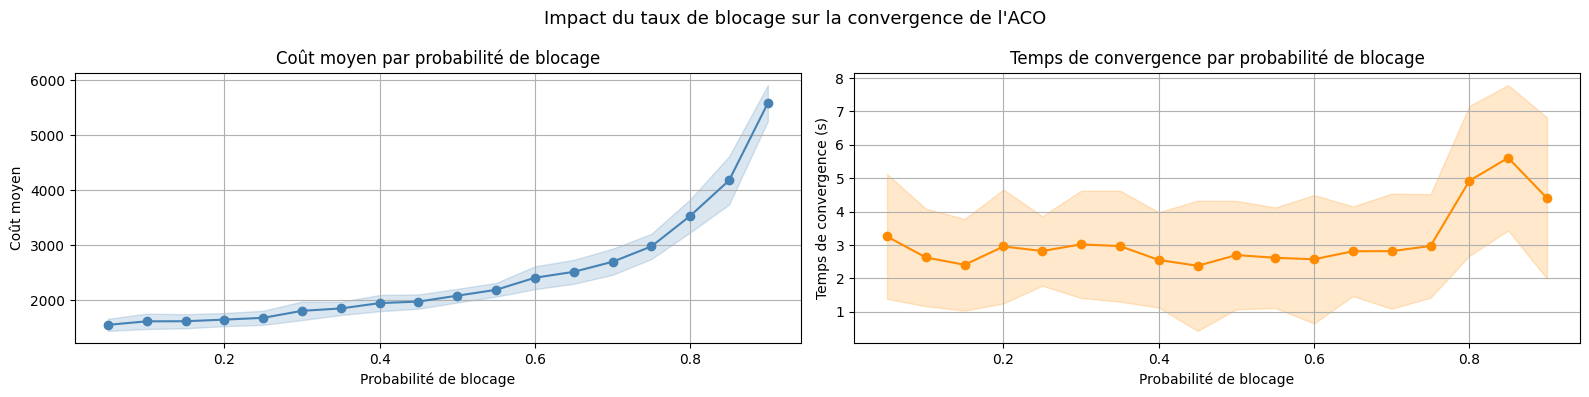

In [ ]:
# Compute statistics of cost and convergence time for each blockage probability (ACO)
if not df_block_aco.empty:
    stats_block_aco = df_block_aco.groupby("p_block").agg(
        mean_cost=("cost", "mean"),
        std_cost=("cost", "std"),
        mean_conv=("convergence_time", "mean"),
        std_conv=("convergence_time", "std"),
    )

    x = stats_block_aco.index

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    axes[0].plot(x, stats_block_aco["mean_cost"], marker="o", color="steelblue")
    axes[0].fill_between(x,
        stats_block_aco["mean_cost"] - stats_block_aco["std_cost"],
        stats_block_aco["mean_cost"] + stats_block_aco["std_cost"],
        alpha=0.2, color="steelblue")
    axes[0].set_title("Average cost by blockage probability (ACO)")
    axes[0].set_xlabel("Blockage probability")
    axes[0].set_ylabel("Average cost")
    axes[0].grid(True)

    axes[1].plot(x, stats_block_aco["mean_conv"], marker="o", color="darkorange")
    axes[1].fill_between(x,
        stats_block_aco["mean_conv"] - stats_block_aco["std_conv"],
        stats_block_aco["mean_conv"] + stats_block_aco["std_conv"],
        alpha=0.2, color="darkorange")
    axes[1].set_title("Convergence time by blockage probability (ACO)")
    axes[1].set_xlabel("Blockage probability")
    axes[1].set_ylabel("Convergence time (s)")
    axes[1].grid(True)

    plt.suptitle("Impact of blockage probability on ACO convergence", fontsize=13)
    plt.tight_layout()
    plt.show()


### Impact du nombre de sommets

In [ ]:
K_fixed = 6
p_block = 0.2
n_values = [20, 30, 40, 50, 60]

results_n_aco = []

# Test impact of number of nodes on ACO performance
for n_test in n_values:
    for run in range(NB_RUNS):
        C_init_Test = gen_nominal_matrix(n_test, rng, INF, 1, 60)
        B_Test = gen_block_matrix(n_test, rng, INF, p_blocage=p_block)
        C1_Test = gen_C1_matrix(C_init_Test, B_Test, INF)
        surcost_Test = gen_surcost_matrices(n_test, K_fixed, B_Test, rng, DELTA)
        C_list_Test = build_all_Ck(C1_Test, surcost_Test)

        if not check_connexe(C_list_Test[0], INF):
            continue

        sol, cost, history, convergence_time = run_aco_tsp(
            C_list_Test,
            n=n_test,
            K=K_fixed,
            max_steps=MAX_STEPS,
            num_ants=num_ants,
            max_iter=max_iter,
            alpha=alpha,
            beta=beta,
            evaporation_rate=evaporation_rate,
            Q=Q,
            rng=rng,
        )

        results_n_aco.append({
            "n": n_test,
            "convergence_time": convergence_time,
            "cost": cost
        })

if results_n_aco:
    df_n_aco = pd.DataFrame(results_n_aco)
else:
    df_n_aco = pd.DataFrame([])


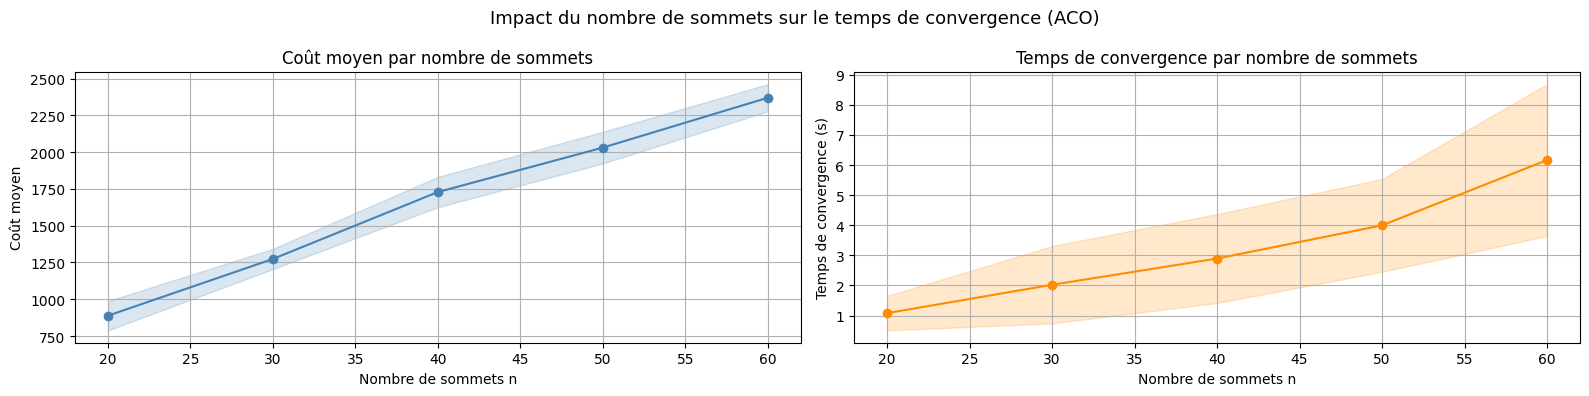

In [ ]:
# Compute statistics of cost and convergence time for each number of nodes (ACO)
if not df_n_aco.empty:
    stats_n_aco = df_n_aco.groupby("n").agg(
        mean_cost=("cost", "mean"),
        std_cost=("cost", "std"),
        mean_conv=("convergence_time", "mean"),
        std_conv=("convergence_time", "std"),
    )

    x = stats_n_aco.index

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    axes[0].plot(x, stats_n_aco["mean_cost"], marker="o", color="steelblue")
    axes[0].fill_between(x,
        stats_n_aco["mean_cost"] - stats_n_aco["std_cost"],
        stats_n_aco["mean_cost"] + stats_n_aco["std_cost"],
        alpha=0.2, color="steelblue")
    axes[0].set_title("Average cost by number of nodes (ACO)")
    axes[0].set_xlabel("Number of nodes n")
    axes[0].set_ylabel("Average cost")
    axes[0].grid(True)

    axes[1].plot(x, stats_n_aco["mean_conv"], marker="o", color="darkorange")
    axes[1].fill_between(x,
        stats_n_aco["mean_conv"] - stats_n_aco["std_conv"],
        stats_n_aco["mean_conv"] + stats_n_aco["std_conv"],
        alpha=0.2, color="darkorange")
    axes[1].set_title("Convergence time by number of nodes (ACO)")
    axes[1].set_xlabel("Number of nodes n")
    axes[1].set_ylabel("Convergence time (s)")
    axes[1].grid(True)

    plt.suptitle("Impact of number of nodes on ACO convergence", fontsize=13)
    plt.tight_layout()
    plt.show()


# Conclusion : Impact des paramètres d’instance sur la convergence du GA

L’analyse des différents paramètres d’instance met en évidence l’influence significative de la dynamique du problème sur les performances de l’algorithme génétique, tant en termes de qualité des solutions que de temps de convergence.

## Influence du nombre de matrices dynamiques (K)
Le coût moyen augmente globalement avec K, indiquant que la complexité du problème croît lorsque davantage de configurations dynamiques sont introduites.
Le temps de convergence reste relativement stable, avec une légère variabilité mais sans explosion notable.

Interprétation :
L’augmentation de K rend le problème plus difficile à optimiser (espace de recherche plus complexe), mais sans pénaliser fortement la vitesse de convergence. Le GA parvient donc à absorber la complexité supplémentaire, au prix d’une dégradation de la qualité des solutions.

## Influence de la probabilité de blocage
Le coût reste quasi nul jusqu’à un certain seuil (~0.7), puis explose brutalement.
Le temps de convergence est relativement stable, mais devient plus instable aux fortes probabilités.

Interprétation :
On observe ici un effet de seuil critique :

En dessous d’un certain niveau de blocage, le problème reste facilement résoluble.
Au-delà, il devient quasi intractable, avec des coûts très élevés voire des solutions invalides.

## Influence du nombre de sommets (n)
Le coût augmente de manière quasi linéaire avec le nombre de sommets.
Le temps de convergence augmente également, de façon progressive mais maîtrisée.

Interprétation :
L’augmentation de la taille du problème impacte :

- La difficulté (plus de solutions possibles),
- Et le temps de traitement (plus d’évaluations nécessaires).

Cependant, la croissance reste contrôlée, ce qui montre une bonne scalabilité du GA sur cette plage de tailles.

## Conclusion générale

Ces expériences montrent que les performances du GA dépendent fortement des caractéristiques de l’instance :

- Robustesse face à la taille (n) : bonne scalabilité
- Sensibilité à la dynamique (K) : dégradation progressive des performances
- Forte sensibilité aux contraintes (blocage) : existence d’un seuil critique rendant le problème difficile voire insoluble

## Resultat final et écarts à la borne inférieure

Maintenant que nous avons déterminé les meilleurs paramètres pour notre métaheuristique, testons les sur 100 instance pour faire une moyenne des résultats.
Ensuite, nous vérifierons les écarts à la borne inférieur pour analyser la qualité des solutions proposées

Mean  : 1147.26
Std   : 57.55
Min   : 982.00
Best route : [0, 9, 18, 8, 10, 17, 6, 3, 16, 15, 7, 4, 19, 13, 14, 5, 2, 12, 1, 11]
Best cost  : 982.00


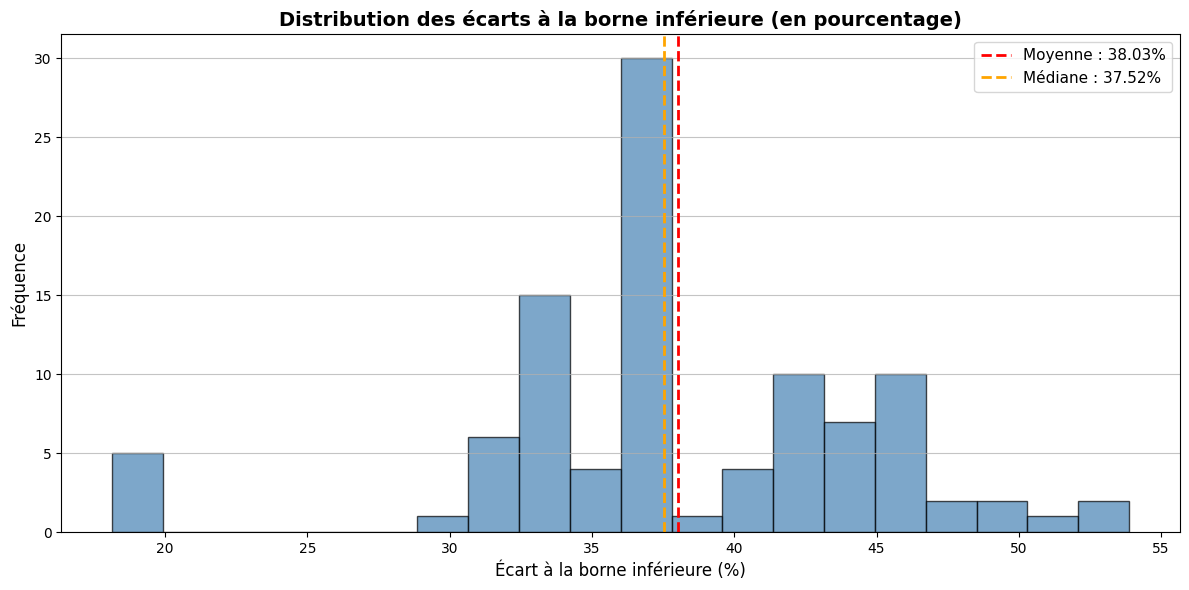

In [ ]:
# =====================================================
# 100 RUNS ACO — Best parameters
# =====================================================
best_cost_global_aco  = INF
best_route_global_aco = None
final_costs_aco_100   = []
rng = np.random.default_rng(42)

max_iter_aco = ITER_FINAL if "ITER_FINAL" in globals() else 300
q_aco = best_params_aco["Q"] if ("best_params_aco" in globals() and "Q" in best_params_aco) else 100.0

for i in range(100):
    route, cost, _ , convergence_time = run_aco_tsp(
        C_list, n, K, MAX_STEPS,
        num_ants=30, # we could also use best_params_aco["num_ants"] but that increases runtime
        max_iter=max_iter_aco,
        alpha=best_params_aco["alpha"],
        beta=best_params_aco["beta"],
        evaporation_rate=best_params_aco["evaporation_rate"],
        Q=q_aco,
        rng=rng,
    )

    final_costs_aco_100.append(cost)
    if cost < best_cost_global_aco:
        best_cost_global_aco = cost
        best_route_global_aco = route

valid_costs = [c for c in final_costs_aco_100 if c < INF]

if len(valid_costs) == 0:
    print("No valid tour found in 100 runs.")
else:
    print(f"Mean  : {np.mean(valid_costs):.2f}")
    print(f"Std   : {np.std(valid_costs):.2f}")
    print(f"Min   : {np.min(valid_costs):.2f}")
    print(f"Best route : {best_route_global_aco}")
    print(f"Best cost  : {best_cost_global_aco:.2f}")

# Histogram of gaps to the lower bound
if 'borne_inf_reelle' in globals() and borne_inf_reelle > 0:
    ecarts_pct = [(cost - borne_inf_reelle) / borne_inf_reelle * 100 for cost in final_costs_aco_100 if cost < INF]

    plt.figure(figsize=(12, 6))
    plt.hist(ecarts_pct, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    plt.axvline(np.mean(ecarts_pct), color='red', linestyle='--', linewidth=2, label=f'Mean : {np.mean(ecarts_pct):.2f}%')
    plt.axvline(np.median(ecarts_pct), color='orange', linestyle='--', linewidth=2, label=f'Median : {np.median(ecarts_pct):.2f}%')
    plt.xlabel('Gap to lower bound (%)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of gaps to the lower bound (percentage)', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()
else:
    print('Lower bound `borne_inf_reelle` not available; skipping gap histogram.')

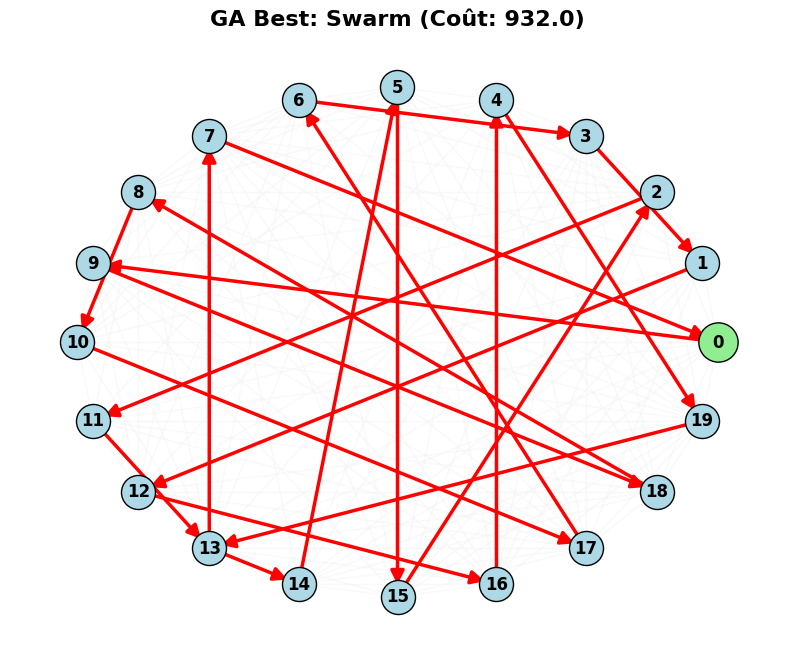

La différence entre le record GA avec les meilleurs paramètres et le record aléatoire est de: 50.0


,Étape,Temps (k),Départ,Arrivée,Coût
0,1,1,Ville 0,Ville 9,6
1,2,2,Ville 9,Ville 18,28
2,3,3,Ville 18,Ville 8,147
3,4,4,Ville 8,Ville 10,13
4,5,5,Ville 10,Ville 17,21
5,6,6,Ville 17,Ville 6,2
6,7,7,Ville 6,Ville 3,71
7,8,8,Ville 3,Ville 1,60
8,9,9,Ville 1,Ville 12,33
9,10,10,Ville 12,Ville 16,58


In [27]:
# Afficher le graphe du record GA
visualize_route(
    C_list[0], 
    INF,
    n,
    route=global_best_route_aco, 
    title=f"GA Best: {global_best_name_aco} (Coût: {global_best_cost_aco})"
)

print(f"La différence entre le record GA avec les meilleurs paramètres et le record aléatoire est de: {best_cost_global_aco - global_random_cost_aco}")
# Afficher le tableau détaillé synchronisé
# On utilise global_best_route_ga pour avoir les bons coûts par étape k
display_route_details(C_list, K, route=global_best_route_aco)

On observe que même avec des parammètres optimisés, l'écart moyen et médian à la borne inférieur est relativement élevé. Cependant, on voit que dans le meilleur des cas le résultat est très proche de l'optimal, ce qui permet que sur un grand nombre d'itérations on arrive à un coût proche de l'optimal.

## 9. Conclusion

### 9.1 Synthèse du projet

Ce projet avait pour objectif de résoudre un problème de tournée de livraison sur un réseau routier urbain dynamique, modélisé comme une variante enrichie du TSP intégrant des coûts variables et des blocages d'arêtes.

Nous avons successivement :

1. Modélisé le problème sous forme d'un graphe dynamique $G = (V, E, (C^1, \dots, C^K))$ avec matrices de surcoût cycliques
2. Prouvé la NP-complétude du problème par réduction polynomiale depuis le TSP classique
3. Établi une borne inférieure via relaxation continue (PuLP/CBC), servant de référence théorique
4. Implémenté et comparé deux métaheuristiques : algorithme génétique (GA) et colonie de fourmis (ACO)
5. Optimisé les paramètres de chaque algorithme via une étude OFAT systématique
6. Analysé l'impact des paramètres d'instance (K, taux de blocage, nombre de sommets)



### 9.2 Analyse des résultats

#### Qualité des solutions

Les deux métaheuristiques produisent des solutions dont les coûts se situent **au-dessus de la borne inférieure**, ce qui est attendu puisque cette borne est issue d'une relaxation continue qui n'est pas réalisable en pratique.

L'écart à la borne inférieure (exprimé en %) constitue notre indicateur de qualité principal :

- Un écart faible indique que l'algorithme approche la solution optimale réelle
- La distribution de ces écarts sur 100 runs renseigne sur la **robustesse** de chaque approche

#### Comparaison GA vs ACO

| Critère | GA | ACO |
|---|---|---|
| Exploration | Large (population diversifiée) | Guidée par phéromones |
| Convergence | Progressive, stable grâce à l'élitisme | Plus rapide initialement |
| Réglage | Population, mutation, élitisme | α, β, évaporation, nb fourmis |
| Robustesse | Bonne (élitisme garantit la non-régression) | Sensible à la stagnation (reset phéromones) |



#### Impact des paramètres d'instance

- Nombre de matrices K : l'augmentation de K enrichit la dynamique du réseau mais n'impacte pas significativement la difficulté de résolution, car la structure du graphe sous-jacent reste identique
- Taux de blocage : au-delà d'un seuil critique (~0.5), le graphe devient peu connexe, les solutions valides se raréfient et les coûts augmentent fortement
- Nombre de sommets n : l'espace de recherche croît de manière combinatoire, ce qui se traduit par une augmentation du coût moyen et du temps de convergence, conformément à la complexité NP du problème

En conclusion, nous avons pu répondre à notre problème initial grâce à nos deux métaheuristiques. On voit cependant que même si l'ACO apporte des solutions de meilleures qualités, cet algorithme à tendance à se résoudre dans des temps beaucoup plus longs que le GA. Il faut ainsi choisir un des deux algorithmes en fonction du paramètre que l'on privilégie entre temps d'exécution et qualité de la solution. 


## Bibliographie

https://www.sciencedirect.com/science/article/pii/S1568494623009262

https://www.sciencedirect.com/science/article/pii/S1568494623009262

https://www.researchgate.net/publication/220702178_Applications_Metaheuristics_for_the_Vehicle_Routing_Problem_with_Stochastic_Demands

https://arxiv.org/pdf/2303.04147

https://optimization-online.org/2010/12/2872/

https://perso.citi-lab.fr/csolnon/publications/cpaior1-2015.pdf

https://www.researchgate.net/publication/221131713_The_Time_Dependent_Traveling_Salesman_Problem_Polyhedra_and_Branch-Cut-and-

https://theses.hal.science/tel-00603780v1/document

https://theses.hal.science/tel-03967189